# 03. Análisis exploratorio de datos - Fashion Transparency Index 2023

### Objetivo del notebook

Esta etapa busca caracterizar el comportamiento general de los indicadores de transparencia corporativa mediante estadísticas descriptivas y visualizaciones, con el fin de identificar patrones de divulgación, comparar las categorías Environment, Social, Governance y Traceability, analizar diferencias según el país de sede y explorar el comportamiento tanto de los indicadores binarios como de los no binarios.

### Descripción general 

El análisis exploratorio constituye una etapa previa al proceso de clustering y tiene como finalidad comprender la estructura y el contenido de la base de datos antes de aplicar técnicas de aprendizaje no supervisado. Para ello, se revisó la composición de la información, se describieron los niveles de divulgación de los indicadores de transparencia y se identificaron aquellos con mayor y menor frecuencia de reporte por parte de las empresas.

Asimismo, se compararon las categorías Environment, Social y Governance (ESG) y se incorporó un análisis descriptivo de los indicadores no binarios con el propósito de comprender las diferentes formas de medición utilizadas por el Fashion Transparency Index y proporcionar un contexto más amplio para la interpretación de los resultados.

In [34]:
# Importamos las librerías necesarias

# Manipulación y análisis de datos
import pandas as pd
import numpy as np
from pathlib import Path

# Visualización
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Normalización y comparación de nombres
import re
import unicodedata
from difflib import SequenceMatcher

# Configuración general de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Definimos las rutas principales del proyecto
ruta_proyecto = Path(
    "/Users/avrilsalazar/Documents/FashionTransparency2023"
)

ruta_datos = ruta_proyecto / "processed"
ruta_figuras = ruta_proyecto / "docs"

# Verificamos que la carpeta de datos procesados exista
if not ruta_datos.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta de datos procesados: {ruta_datos}"
    )

# Creamos la carpeta de figuras si todavía no existe
ruta_figuras.mkdir(
    parents=True,
    exist_ok=True
)

print("Rutas del proyecto configuradas correctamente.")

# Definimos una paleta profesional para todo el análisis
AZUL_MARINO = "#17324D"
AZUL_SECUNDARIO = "#506B84"
GRIS_OSCURO = "#4A4A4A"
GRIS_MEDIO = "#A7ADB4"
GRIS_CLARO = "#E6E9ED"
NEGRO = "#1A1A1A"

# Establecemos una configuración visual general
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRIS_MEDIO,
    "axes.labelcolor": NEGRO,
    "axes.titlecolor": NEGRO,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.color": GRIS_OSCURO,
    "ytick.color": GRIS_OSCURO,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10
})

Rutas del proyecto configuradas correctamente.


In [35]:
# Función para guardar las figuras del análisis

def guardar_figura(fig, nombre_archivo):
    """
    Guarda una figura en alta resolución dentro de la carpeta docs.
    """

    fig.savefig(
        ruta_figuras / f"{nombre_archivo}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

In [36]:
# Cargamos la base de datos limpia obtenida
# en el notebook anterior

base = pd.read_csv(
    ruta_datos / "base_integrada_limpia.csv"
)

# Mostramos las primeras observaciones para verificar
# que la carga fue correcta

base.head()

,Answer Page,Metric,Company,Year,Value,Source Page,Answer ID,Original Source,Source Count,Comments,ISIN,Pais_sede,Fuente_pais,Categoria
0,https://wikirate.org/Fashion_Revolution+Fashion_Transparency_Index_2023+Puma+2023,Fashion Revolution+Fashion Transparency Index 2023,Puma,2023,6.6399545215046025,NaN,NaN,NaN,NaN,NaN,DE0006969603;US7458781082;US7458782072,Alemania,https://www.about.puma.com/en/contact,Environment
1,https://wikirate.org/Fashion_Revolution+5_Spotlight_Issues_Score_2023+Puma+2023,Fashion Revolution+5. Spotlight Issues Score (2023),Puma,2023,5.777737773332444,NaN,NaN,NaN,NaN,NaN,DE0006969603;US7458781082;US7458782072,Alemania,https://www.about.puma.com/en/contact,Environment
2,https://wikirate.org/~15202791,Fashion Revolution+Zero Deforestation Progress,Puma,2023,1,https://wikirate.org/~15072139,"15,202,791.000",https://annual-report.puma.com/2021/downloads/puma-ar-2021_annual-report.pdf,1.000,"Page(s) 16, Page(s) 116117",DE0006969603;US7458781082;US7458782072,Alemania,https://www.about.puma.com/en/contact,Environment
3,https://wikirate.org/Fashion_Revolution+Fashion_Transparency_Index_2023+H_M+2023,Fashion Revolution+Fashion Transparency Index 2023,H&M,2023,7.109952921622202,NaN,NaN,NaN,NaN,NaN,SE0000106270;SE0000106288;SE0000157521;SE0000157539;SE0000160731;SE0000160749,Suecia,https://hmgroup.com/about-us/contact-us/,Environment
4,https://wikirate.org/Fashion_Revolution+5_Spotlight_Issues_Score_2023+H_M+2023,Fashion Revolution+5. Spotlight Issues Score (2023),H&M,2023,6.4443777733324445,NaN,NaN,NaN,NaN,NaN,SE0000106270;SE0000106288;SE0000157521;SE0000157539;SE0000160731;SE0000160749,Suecia,https://hmgroup.com/about-us/contact-us/,Environment


### Revisión de la estructura de la base de datos

Antes de iniciar el análisis exploratorio, se revisa la estructura general de la base de datos. Esta verificación permite conocer el número de observaciones y variables disponibles, identificar el tipo de dato de cada columna y confirmar que la información fue importada correctamente.

In [37]:
# Consultamos las dimensiones de la base de datos
# El resultado indica el número de filas (observaciones)
# y columnas (variables) contenidas en la base

print(f"Dimensiones de la base: {base.shape[0]} filas y {base.shape[1]} columnas")

# Mostramos la información general de la base
# Se presenta el nombre de cada variable, el número de valores no nulos
# y el tipo de dato almacenado en cada columna
base.info()

Dimensiones de la base: 32250 filas y 14 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32250 entries, 0 to 32249
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Answer Page      32250 non-null  object 
 1   Metric           32250 non-null  object 
 2   Company          32250 non-null  object 
 3   Year             32250 non-null  int64  
 4   Value            30994 non-null  object 
 5   Source Page      30750 non-null  object 
 6   Answer ID        10250 non-null  float64
 7   Original Source  10250 non-null  object 
 8   Source Count     10250 non-null  float64
 9   Comments         1973 non-null   object 
 10  ISIN             2655 non-null   object 
 11  Pais_sede        32250 non-null  object 
 12  Fuente_pais      32250 non-null  object 
 13  Categoria        32250 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 3.4+ MB


### Revisión de valores faltantes

Como parte de la caracterización inicial de la base de datos, se verifica la presencia de valores faltantes en cada una de las variables. Esta revisión permite confirmar la integridad de la información e identificar qué variables presentan información incompleta y considerar esta característica durante los análisis posteriores.

In [38]:
# Calculamos el número de valores faltantes por variable

valores_faltantes = base.isna().sum()

# Mostramos únicamente las variables que presentan valores faltantes
valores_faltantes = valores_faltantes[valores_faltantes > 0]

# Presentamos el resumen de valores faltantes
display(valores_faltantes.to_frame(name="Valores faltantes"))

,Valores faltantes
Value,1256
Source Page,1500
Answer ID,22000
Original Source,22000
Source Count,22000
Comments,30277
ISIN,29595


Los valores faltantes se concentran en variables asociadas a información complementaria proporcionada por WikiRate, como identificadores de respuesta, fuentes originales, comentarios e identificadores ISIN. Estos campos no forman parte de la información utilizada en el análisis de transparencia y, por tanto, su ausencia no afecta la construcción de la base de datos ni las etapas posteriores del análisis. Adicionalmente, la variable Value presenta valores faltantes asociados a algunos indicadores no binarios. Los **indicadores binarios** que serán utilizados para el análisis de agrupamiento fueron previamente verificados y **no presentan valores faltantes**.


### Composición general de la base de datos

Como primer paso del análisis exploratorio, se resume la composición general de la base de datos mediante el número de empresas, indicadores y observaciones incluidas. Esta revisión permite confirmar la cobertura de la información que será utilizada en las etapas posteriores del análisis.

In [39]:
# Calculamos un resumen general de la base de datos

resumen_base = pd.DataFrame({
    "Característica": [
        "Observaciones",
        "Empresas",
        "Indicadores",
        "Años"
    ],
    "Valor": [
        len(base),
        base["Company"].nunique(),
        base["Metric"].nunique(),
        base["Year"].nunique()
    ]
})

# Mostramos el resumen
display(resumen_base)

,Característica,Valor
0,Observaciones,32250
1,Empresas,250
2,Indicadores,129
3,Años,1


### Validación de consistencia de los datos con el informe oficial

Se evaluó que la información contenida en la base integrada fuera consistente con la documentación oficial del *Fashion Transparency Index 2023*. Para ello, se revisó el informe publicado por Fashion Revolution, el cual describe el alcance del índice, las empresas evaluadas, la metodología empleada y los principales resultados correspondientes a la edición 2023.

La base de datos utilizada en este proyecto fue obtenida mediante las descargas disponibles en WikiRate. El propio informe del *Fashion Transparency Index 2023* señala que Fashion Revolution mantiene una colaboración con esta plataforma para que los datos recopilados sobre las empresas sean de libre acceso, fácilmente comparables, legibles por máquina y utilizables para investigación y otros procesos de análisis. En palabras del informe: *"Our partnership with WikiRate enables the data we collect about brands to be freely accessible, easily comparable, machine-readable, and crucially, actionable"* (Fashion Revolution, 2023, p. 30). En español: *"Nuestra colaboración con WikiRate permite que los datos que recopilamos sobre las marcas sean de libre acceso, fácilmente comparables, legibles por máquina y, de manera crucial, utilizables para la toma de decisiones"*.

Para fines del análisis, los indicadores fueron clasificados en las categorías temáticas Environment, Social, Governance y Traceability mediante el diccionario de indicadores construido durante la primera etapa del proyecto. Esta clasificación toma como referencia la organización temática de la información disponible en WikiRate y no corresponde a las secciones metodológicas empleadas por el informe oficial para presentar sus resultados.

El número de métricas disponible en la base descargada desde WikiRate difiere del número de indicadores descritos en la documentación metodológica del índice. Debido a que el portal oficial no permitió la descarga del **Brand Questionnaire Template** durante el periodo de esta investigación, esta diferencia no pudo verificarse directamente. En consecuencia, la validación de la base se realizará mediante dos verificaciones. En primer lugar, se comprobará que las empresas incluidas en la base correspondan con las reportadas en el informe oficial. Posteriormente, se contrastarán diversos resultados publicados en el informe con los obtenidos a partir de la base integrada, con el propósito de identificar posibles coincidencias o anomalias. 

**Validación 1. Comparación de empresas con el informe oficial**

In [40]:
# Lista de las 250 marcas incluidas en el apartado
# "A–Z of Brands" del Fashion Transparency Index 2023.

# Se utilizan únicamente los nombres principales de las marcas,
# sin incluir entre paréntesis el grupo empresarial o la empresa matriz.

empresas_informe_oficial = [
    "Abercrombie & Fitch",
    "Adidas",
    "Aeropostale",
    "AJIO",
    "ALDI Nord",
    "ALDI SOUTH",
    "ALDO",
    "Amazon",
    "American Eagle",
    "ANTA",
    "Anthropologie",
    "Aritzia",
    "Armani",
    "Asda (George.)",
    "ASICS",
    "ASOS",
    "Balenciaga",
    "Bally",
    "Banana Republic",
    "BCBGMAXAZRIA",
    "Beanpole",
    "Belle",
    "Bershka",
    "Big Bazaar – ffb",
    "Big W",
    "Billabong",
    "Bloomingdale's",
    "Bonprix",
    "boohoo",
    "Bosideng",
    "Bottega Veneta",
    "Brooks Sports",
    "Brunello Cucinelli",
    "Buckle",
    "Burberry",
    "Burlington",
    "C&A",
    "Calvin Klein",
    "Calzedonia",
    "Canada Goose",
    "Carhartt",
    "Carolina Herrera",
    "CAROLL",
    "Carrefour",
    "Carter's",
    "CELINE",
    "celio",
    "Champion",
    "Chanel",
    "Chico's",
    "Chloé",
    "Clarks",
    "COACH",
    "Columbia Sportswear",
    "Converse",
    "Cortefiel",
    "Costco",
    "Cotton On",
    "Decathlon",
    "Deichmann",
    "Desigual",
    "Dick's Sporting Goods",
    "Diesel",
    "Dillard's",
    "Dior",
    "Disney",
    "DKNY",
    "Dolce & Gabbana",
    "Dr. Martens",
    "Dressmann",
    "DSW",
    "Eddie Bauer",
    "El Corte Inglés",
    "Ermenegildo Zegna",
    "Esprit",
    "Express",
    "Fabletics",
    "Falabella",
    "Famous Footwear",
    "Fanatics",
    "Fashion Nova",
    "Fendi",
    "Fila",
    "Fjällräven",
    "Foot Locker",
    "Foschini",
    "Fossil",
    "Free People",
    "Fruit of the Loom",
    "Furla",
    "G-Star RAW",
    "Gap",
    "Gerry Weber",
    "Gildan",
    "GU",
    "Gucci",
    "GUESS",
    "Gymshark",
    "H&M",
    "Hanes",
    "Heilan Home",
    "Helly Hansen",
    "HEMA",
    "Hermès",
    "Hollister Co.",
    "Hudson's Bay",
    "Hugo Boss",
    "Intimissimi",
    "Ito-Yokado",
    "Jack & Jones",
    "Jack Wolfskin",
    "JD Sports",
    "Jil Sander",
    "Jockey",
    "Joe Fresh",
    "John Lewis",
    "Jordan",
    "K-Way",
    "Kate Spade",
    "Kathmandu",
    "Kaufland",
    "Kiabi",
    "KiK",
    "Kmart",
    "Kmart Australia",
    "Kohl's",
    "KOOVS",
    "La Redoute",
    "Lacoste",
    "Lands' End",
    "LC Waikiki",
    "Levi Strauss & Co",
    "Li-Ning",
    "Lidl",
    "Lindex",
    "LL Bean",
    "Longchamp",
    "Louis Vuitton",
    "Lululemon",
    "Macy's",
    "Mammut",
    "Mango",
    "Marc Jacobs",
    "Marks & Spencer",
    "Marni",
    "Massimo Dutti",
    "Matalan",
    "Max",
    "Max Mara",
    "Merrell",
    "Metersbonwe",
    "Mexx",
    "Michael Kors",
    "Miu Miu",
    "Mizuno",
    "Moncler",
    "Monoprix",
    "Morrisons",
    "MRP",
    "Muji",
    "New Balance",
    "New Look",
    "New Yorker",
    "Next",
    "Nike",
    "Nine West",
    "Nordstrom",
    "Old Navy",
    "Otto",
    "OVS",
    "Paris",
    "Patagonia",
    "Pepe Jeans",
    "Pimkie",
    "Prada",
    "PrettyLittleThing",
    "Primark",
    "Prisma",
    "Pull&Bear",
    "Puma",
    "Quiksilver",
    "Ralph Lauren",
    "Reebok",
    "REI",
    "Reliance Trends",
    "Reserved",
    "REVOLVE",
    "River Island",
    "Romwe",
    "Ross Dress for Less",
    "Roxy",
    "Russell Athletic",
    "s.Oliver",
    "Sainsbury's",
    "SAINT LAURENT",
    "Saks Fifth Avenue",
    "Salvatore Ferragamo",
    "Sandro",
    "Savage X Fenty",
    "Semir",
    "SHEIN",
    "Shimamura",
    "Skechers",
    "Speedo",
    "Splash",
    "Sports Direct",
    "Steve Madden",
    "Stradivarius",
    "Superdry",
    "Takko",
    "Target",
    "Target Australia",
    "Tchibo",
    "Ted Baker",
    "Tesco (F&F Clothing)",
    "Tezenis",
    "The Children's Place",
    "The North Face",
    "The Warehouse",
    "Timberland",
    "TJ Maxx",
    "Tod's",
    "Tom Ford",
    "Tom Tailor",
    "Tommy Bahama",
    "Tommy Hilfiger",
    "TOPVALU COLLECTION",
    "Tory Burch",
    "Triumph",
    "Truworths",
    "UGG",
    "Under Armour",
    "Uniqlo",
    "United Arrows",
    "United Colors of Benetton",
    "Urban Outfitters",
    "Valentino",
    "Van Heusen",
    "Vans",
    "Vero Moda",
    "Versace",
    "Very",
    "Victoria's Secret",
    "Walmart",
    "Woolworths South Africa",
    "Wrangler",
    "Youngor",
    "Zalando",
    "Zara",
    "Zeeman"
]


# Verificamos que la lista transcrita contenga exactamente
# las 250 empresas indicadas en el informe oficial.
print(
    "Empresas en la lista oficial:",
    len(set(empresas_informe_oficial))
)


# Extraemos los nombres únicos de las empresas disponibles
# en la base integrada.
empresas_base = (
    base["Company"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print(
    "Empresas únicas en la base integrada:",
    len(empresas_base)
)

Empresas en la lista oficial: 250
Empresas únicas en la base integrada: 250


In [41]:
# Definimos una función para normalizar los nombres

def normalizar_nombre(nombre):
    """
    Normaliza el nombre de una empresa para facilitar su comparación.

    El procedimiento:
    1. Convierte el nombre a minúsculas.
    2. Sustituye el símbolo & por la palabra 'and'.
    3. Elimina acentos.
    4. Elimina signos de puntuación.
    5. Elimina terminaciones jurídicas frecuentes.
    6. Une las palabras restantes en una sola cadena.
    """

    # Convertimos el valor a texto, eliminamos espacios externos
    # y utilizamos minúsculas.
    nombre = str(nombre).strip().lower()

    # Unificamos símbolos y diferentes tipos de guion.
    nombre = nombre.replace("&", " and ")
    nombre = nombre.replace("–", " ")
    nombre = nombre.replace("—", " ")
    nombre = nombre.replace("-", " ")

    # Separamos las letras de sus acentos.
    nombre = unicodedata.normalize("NFKD", nombre)

    # Eliminamos los caracteres correspondientes a los acentos.
    nombre = "".join(
        caracter
        for caracter in nombre
        if not unicodedata.combining(caracter)
    )

    # Sustituimos cualquier signo de puntuación por un espacio.
    nombre = re.sub(r"[^a-z0-9\s]", " ", nombre)

    # Separamos el nombre en palabras.
    palabras = nombre.split()

    # Definimos términos jurídicos y empresariales que pueden aparecer
    # en WikiRate, pero no necesariamente en el informe oficial.
    terminos_genericos = {
        "the",
        "ag",
        "se",
        "spa",
        "inc",
        "incorporated",
        "corp",
        "corporation",
        "company",
        "co",
        "limited",
        "ltd",
        "llc",
        "plc"
    }

    # Conservamos únicamente las palabras informativas del nombre.
    palabras_limpias = [
        palabra
        for palabra in palabras
        if palabra not in terminos_genericos
    ]

    # Unimos las palabras sin espacios.
    return "".join(palabras_limpias)

In [42]:
# Creamos una tabla con los nombres del informe oficial

tabla_empresas_oficial = pd.DataFrame({
    "Empresa_oficial": empresas_informe_oficial
})

tabla_empresas_oficial["Nombre_normalizado"] = (
    tabla_empresas_oficial["Empresa_oficial"]
    .apply(normalizar_nombre)
)


# Creamos una tabla con los nombres de la base integrada
tabla_empresas_base = pd.DataFrame({
    "Empresa_base": empresas_base
})

tabla_empresas_base["Nombre_normalizado"] = (
    tabla_empresas_base["Empresa_base"]
    .apply(normalizar_nombre)
)


# Mostramos las primeras observaciones para verificar
# que la normalización se realizó correctamente.
display(tabla_empresas_oficial.head())
display(tabla_empresas_base.head())

,Empresa_oficial,Nombre_normalizado
0,Abercrombie & Fitch,abercrombieandfitch
1,Adidas,adidas
2,Aeropostale,aeropostale
3,AJIO,ajio
4,ALDI Nord,aldinord


,Empresa_base,Nombre_normalizado
0,AJIO,ajio
1,ALDO,aldo
2,Abercrombie & Fitch,abercrombieandfitch
3,Adidas AG,adidas
4,Aeropostale Inc.,aeropostale


In [43]:
# Identificamos las empresas cuyos nombres coinciden
# después de aplicar la normalización.

coincidencias_directas = tabla_empresas_oficial.merge(
    tabla_empresas_base,
    on="Nombre_normalizado",
    how="inner"
)


# Verificamos que ninguna empresa haya producido
# más de una correspondencia directa.
duplicados_oficial = (
    coincidencias_directas["Empresa_oficial"]
    .duplicated()
    .sum()
)

duplicados_base = (
    coincidencias_directas["Empresa_base"]
    .duplicated()
    .sum()
)

print(
    "Coincidencias directas después de normalizar:",
    len(coincidencias_directas)
)

print(
    "Empresas oficiales duplicadas en la correspondencia:",
    duplicados_oficial
)

print(
    "Empresas de la base duplicadas en la correspondencia:",
    duplicados_base
)

Coincidencias directas después de normalizar: 181
Empresas oficiales duplicadas en la correspondencia: 0
Empresas de la base duplicadas en la correspondencia: 0


In [44]:
# Identificamos las empresas del informe oficial que todavía
# no encontraron una correspondencia directa.

oficiales_coincidentes = set(
    coincidencias_directas["Empresa_oficial"]
)

empresas_oficiales_pendientes = (
    tabla_empresas_oficial[
        ~tabla_empresas_oficial["Empresa_oficial"]
        .isin(oficiales_coincidentes)
    ]
    .copy()
)


# Identificamos las empresas de la base integrada que todavía
# no encontraron una correspondencia directa.
base_coincidente = set(
    coincidencias_directas["Empresa_base"]
)

empresas_base_pendientes = (
    tabla_empresas_base[
        ~tabla_empresas_base["Empresa_base"]
        .isin(base_coincidente)
    ]
    .copy()
)


print(
    "Empresas oficiales pendientes:",
    len(empresas_oficiales_pendientes)
)

print(
    "Empresas de la base pendientes:",
    len(empresas_base_pendientes)
)

Empresas oficiales pendientes: 69
Empresas de la base pendientes: 69


In [45]:
# Preparamos las empresas pendientes de ambas fuentes
# para realizar la revisión manual.

empresas_pendientes_revision = pd.DataFrame({
    "Empresa_oficial": (
        empresas_oficiales_pendientes["Empresa_oficial"]
        .reset_index(drop=True)
    ),
    "Empresa_base_pendiente": (
        empresas_base_pendientes["Empresa_base"]
        .reset_index(drop=True)
    )
})


# Agregamos columnas vacías para registrar manualmente
# la correspondencia y cualquier observación necesaria.
empresas_pendientes_revision["Empresa_base_asignada"] = ""
empresas_pendientes_revision["Observación"] = ""


print(
    "Empresas oficiales pendientes:",
    len(empresas_oficiales_pendientes)
)

print(
    "Empresas de la base pendientes:",
    len(empresas_base_pendientes)
)

display(empresas_pendientes_revision)

# Exportamos ambas listas en un mismo archivo de Excel.
empresas_pendientes_revision.to_excel(
    ruta_datos / "empresas_pendientes_revision.xlsx",
    index=False
)

print("Archivo exportado correctamente.")

Empresas oficiales pendientes: 69
Empresas de la base pendientes: 69


,Empresa_oficial,Empresa_base_pendiente,Empresa_base_asignada,Observación
0,ALDI SOUTH,Airwair International Ltd (Dr Martens),,
1,Amazon,Aldi Sud,,
2,American Eagle,"Amazon.com, Inc.",,
3,ANTA,American Eagle Outfitters,,
4,Armani,Anta Sports Products,,
...,...,...,...,...
64,TOPVALU COLLECTION,Topvalu,,
65,Triumph,Triumph International,,
66,Versace,Warehouse Group,,
67,Very,Woolworths Holdings Limited,,


Archivo exportado correctamente.


In [46]:
# Definimos manualmente la correspondencia de las 69 empresas
# que no coincidieron automáticamente después de normalizar.

correspondencias_manuales = {
    "ALDI SOUTH": "Aldi Sud",
    "Amazon": "Amazon.com, Inc.",
    "American Eagle": "American Eagle Outfitters",
    "ANTA": "Anta Sports Products",
    "Armani": "Giorgio Armani SpA",
    "Asda (George.)": "George (brand)",
    "Belle": "Belle International Holdings",
    "Big Bazaar – ffb": "Smart Bazaar",
    "Billabong": "Billabong International Ltd",
    "boohoo": "Boohoo Group plc (trading as Debenhams Group)",
    "Bosideng": "Bosideng International Holdings Limited",
    "Burberry": "Burberry Group plc",
    "Burlington": "Burlington Stores Inc",
    "Carrefour": "Carrefour S.A.",
    "celio": "Celio International",
    "Chanel": "Chanel SA",
    "Chico's": "Chico's FAS Inc",
    "Clarks": "C&J Clark International",
    "COACH": "Coach Stores Limited",
    "Cortefiel": "Cortefiel SA",
    "Costco": "Costco Wholesale",
    "Cotton On": "Cotton on Group",
    "Decathlon": "Decathlon Group",
    "Dior": "Christian Dior",
    "Disney": "The Walt Disney Company",
    "Dr. Martens": "Airwair International Ltd (Dr Martens)",
    "El Corte Inglés": "El Corte Ingles S.A.",
    "Esprit": "Esprit Holdings Limited",
    "Fossil": "Fossil Group, Inc.",
    "Gildan": "Gildan Activewear Inc.",
    "Hanes": "Hanesbrands",
    "Helly Hansen": "Helly Hansen AS",
    "Hermès": "Hermes International",
    "Intimissimi": "Intimissimi S.p.A",
    "JD Sports": "JD Sports Fashion plc",
    "Jockey": "Jockey International Inc",
    "Jordan": "Jordan (Brand)",
    "Kate Spade": "Kate Spade & Company",
    "Kathmandu": "Kathmandu Holdings Ltd",
    "KiK": "KiK Textilien und Non-Food GmbH",
    "Louis Vuitton": "Louis Vuitton Malletier SA (LVMH)",
    "Lululemon": "lululemon athletica",
    "Mammut": "Mammut Sports Group AG",
    "Mango": "MANGO (Punto Fa, S.L.)",
    "Marks & Spencer": "Marks and Spencer Group plc",
    "Massimo Dutti": "Massimo Dutti S.A.",
    "Max": "Max Fashion",
    "Michael Kors": "Capri Holdings Ltd (formerly Michael Kors)",
    "Morrisons": "Nutmeg at Morrisons",
    "MRP": "Mr Price",
    "New Balance": "New Balance Athletic Shoe, Inc.",
    "New Look": "New Look Retail Group",
    "Otto": "Otto Group",
    "Paris": "Paris (Almacenes Paris)",
    "Prisma": "SOK S Group",
    "Reebok": "Reebok International Ltd.",
    "Ross Dress for Less": "Ross Stores",
    "Skechers": "Skechers USA Inc",
    "Speedo": "Speedo International Limited",
    "Takko": "Takko Holding GmbH",
    "Tchibo": "Tchibo GmbH",
    "Tesco (F&F Clothing)": "F&F",
    "The Warehouse": "Warehouse Group",
    "Tom Ford": "Tom Ford International LLC",
    "TOPVALU COLLECTION": "Topvalu",
    "Triumph": "Triumph International",
    "Versace": "Gianni Versace S.r.l.",
    "Very": "The Very Group",
    "Woolworths South Africa": "Woolworths Holdings Limited"
}


# Asignamos a cada empresa oficial su correspondencia
# identificada manualmente en la base integrada.
empresas_pendientes_revision["Empresa_base_asignada"] = (
    empresas_pendientes_revision["Empresa_oficial"]
    .map(correspondencias_manuales)
)


# Verificamos que las 69 empresas hayan sido asignadas
# y que ninguna empresa de la base se utilice más de una vez.
print(
    "Correspondencias manuales completadas:",
    empresas_pendientes_revision["Empresa_base_asignada"]
    .notna()
    .sum()
)

print(
    "Empresas de la base asignadas más de una vez:",
    empresas_pendientes_revision["Empresa_base_asignada"]
    .duplicated()
    .sum()
)

display(
    empresas_pendientes_revision[
        [
            "Empresa_oficial",
            "Empresa_base_asignada"
        ]
    ]
)

Correspondencias manuales completadas: 69
Empresas de la base asignadas más de una vez: 0


,Empresa_oficial,Empresa_base_asignada
0,ALDI SOUTH,Aldi Sud
1,Amazon,"Amazon.com, Inc."
2,American Eagle,American Eagle Outfitters
3,ANTA,Anta Sports Products
4,Armani,Giorgio Armani SpA
...,...,...
64,TOPVALU COLLECTION,Topvalu
65,Triumph,Triumph International
66,Versace,Gianni Versace S.r.l.
67,Very,The Very Group


In [47]:
# Comprobamos que las correspondencias automáticas y manuales
# cubran la totalidad de las empresas incluidas en el informe.

total_empresas = (
    len(coincidencias_directas)
    + len(empresas_pendientes_revision)
)

print("Coincidencias automáticas:", len(coincidencias_directas))
print("Correspondencias manuales:", len(empresas_pendientes_revision))
print("Total de empresas validadas:", total_empresas)
print("Empresas del informe oficial:", len(empresas_informe_oficial))


# Verificamos que no existan empresas repetidas
# dentro de las correspondencias manuales.
duplicadas_manuales = (
    empresas_pendientes_revision["Empresa_base_asignada"]
    .duplicated()
    .sum()
)

print(
    "Empresas de la base asignadas más de una vez:",
    duplicadas_manuales
)

Coincidencias automáticas: 181
Correspondencias manuales: 69
Total de empresas validadas: 250
Empresas del informe oficial: 250
Empresas de la base asignadas más de una vez: 0


La normalización de los nombres permitió identificar automáticamente **181 correspondencias** entre ambas fuentes. Las **69** restantes fueron revisadas manualmente debido a diferencias en la forma de registrar los nombres. Tras esta revisión, se comprobó que las **250 empresas** del informe oficial cuentan con una **correspondencia razonable** en la base integrada.

**Validación 2. Comparación con resultados del informe oficial**

*Coincidencia del indicador Compromiso con el decrecimiento (Commitment to Degrowth)*

El Fashion Transparency Index 2023 reporta que únicamente **2 empresas** divulgaron información correspondiente al indicador **Compromiso con el decrecimiento** (*Commitment to Degrowth*), el cual identifica a las empresas que manifiestan públicamente su compromiso de reducir o limitar el crecimiento de su producción con el fin de disminuir sus impactos ambientales. Para verificar la consistencia de la base integrada, se identifica el número de empresas que registran una respuesta afirmativa para este indicador y se compara con el valor publicado en el informe oficial.

In [48]:
# Filtramos el indicador de interés.

degrowth = base.loc[
    base["Metric"] == "Fashion Revolution+Commitment to Degrowth",
    ["Company", "Value"]
].copy()

# Convertimos los valores a formato numérico.
degrowth["Value"] = pd.to_numeric(
    degrowth["Value"],
    errors="coerce"
)

# Seleccionamos únicamente las empresas que divulgaron el indicador.
empresas_degrowth = degrowth.loc[
    degrowth["Value"] == 1,
    ["Company"]
]

print(f"Número de empresas identificadas: {len(empresas_degrowth)}")

display(empresas_degrowth.reset_index(drop=True))

Número de empresas identificadas: 2


,Company
0,Giorgio Armani SpA
1,United Colors of Benetton


La base integrada identifica **2 empresas** que divulgaron información correspondiente a este indicador: **Giorgio Armani SpA** y **United Colors of Benetton**. Este resultado coincide con el valor reportado en el *Fashion Transparency Index 2023*, donde se señala que estas mismas empresas son las únicas que manifiestan públicamente este compromiso (p. 11), lo que aporta evidencia adicional sobre la consistencia de la información integrada.

*Coincidencia del indicador Divulgación del número de convenios colectivos que establecen salarios superiores al mínimo legal (Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum)*

El *Fashion Transparency Index 2023* reporta que únicamente **3 empresas** divulgaron información correspondiente al indicador **Divulgación del número de convenios colectivos que establecen salarios superiores al mínimo legal** (*Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum*). Este indicador identifica a las empresas que informan públicamente el número de convenios colectivos mediante los cuales sus trabajadores reciben salarios superiores al mínimo legal vigente en el país donde operan. Para verificar la consistencia de la base integrada, se identifica la cantidad de empresas que registran una respuesta afirmativa para este indicador y se compara con el valor dentro del informe oficial. 

In [49]:
# Filtramos el indicador de interés.

collective_bargaining = base.loc[
    base["Metric"] == "Fashion Revolution+Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum",
    ["Company", "Value"]
].copy()

# Convertimos los valores a formato numérico.
collective_bargaining["Value"] = pd.to_numeric(
    collective_bargaining["Value"],
    errors="coerce"
)

# Seleccionamos únicamente las empresas que divulgaron el indicador.
empresas_collective = collective_bargaining.loc[
    collective_bargaining["Value"] == 1,
    ["Company"]
]

print(f"Número de empresas identificadas: {len(empresas_collective)}")

display(empresas_collective.reset_index(drop=True))

Número de empresas identificadas: 3


,Company
0,Superdry plc
1,Gucci
2,OVS SpA


La base integrada identifica **3 empresas** que divulgaron información correspondiente a este indicador. Este resultado coincide con el valor reportado en el *Fashion Transparency Index 2023*, donde se señala que únicamente el **1 %** de las 250 empresas evaluadas divulga esta información (p. 14), lo que aporta evidencia adicional sobre la consistencia de la información integrada.

*Coincidencia del indicador Publicación de un contrato estándar para proveedores (Publishes Standard Supplier Agreement Template)*

El *Fashion Transparency Index 2023* reporta que únicamente **1 empresa** divulgó información correspondiente al indicador **Publicación de un contrato estándar para proveedores** (*Publishes Standard Supplier Agreement Template*). Este indicador identifica a las empresas que publican un modelo o plantilla del contrato utilizado con sus proveedores, en el que se establecen las condiciones habituales de pedido y pago. Para verificar la consistencia de la base integrada, se identifica el número de empresas que registran una respuesta afirmativa para este indicador y se compara con el valor compartido en el informe oficial.

In [50]:
# Filtramos el indicador de interés.

supplier_contract = base.loc[
    base["Metric"] == "Fashion Revolution+Publishes Standard Supplier Agreement Template",
    ["Company", "Value"]
].copy()

# Convertimos los valores a formato numérico.
supplier_contract["Value"] = pd.to_numeric(
    supplier_contract["Value"],
    errors="coerce"
)

# Seleccionamos únicamente las empresas que divulgaron el indicador.
empresas_supplier_contract = supplier_contract.loc[
    supplier_contract["Value"] == 1,
    ["Company"]
]

print(
    f"Número de empresas identificadas: "
    f"{len(empresas_supplier_contract)}"
)

display(
    empresas_supplier_contract.reset_index(drop=True)
)

Número de empresas identificadas: 2


,Company
0,Zeeman
1,Takko Holding GmbH


La base integrada identifica **2 empresas** que divulgaron información correspondiente a este indicador. Este resultado difiere del valor reportado en el *Fashion Transparency Index 2023*, donde se señala que únicamente **Zeeman** publica una plantilla de contrato estándar para proveedores alineada con procesos de debida diligencia (p. 10). Debido a esta diferencia, se realiza una revisión detallada de los registros correspondientes con el fin de identificar el posible origen de la discrepancia entre ambas fuentes.

In [51]:
# Recuperamos todos los registros correspondientes al indicador.

revision_supplier_contract = base.loc[
    base["Metric"] == "Fashion Revolution+Publishes Standard Supplier Agreement Template"
].copy()

# Convertimos el valor a formato numérico.
revision_supplier_contract["Value"] = pd.to_numeric(
    revision_supplier_contract["Value"],
    errors="coerce"
)

# Mostramos únicamente las empresas con respuesta afirmativa.
revision_supplier_contract = (
    revision_supplier_contract
    .loc[revision_supplier_contract["Value"] == 1]
    .sort_values("Company")
    .reset_index(drop=True)
)

display(revision_supplier_contract)

,Answer Page,Metric,Company,Year,Value,Source Page,Answer ID,Original Source,Source Count,Comments,ISIN,Pais_sede,Fuente_pais,Categoria
0,https://wikirate.org/~15131356,Fashion Revolution+Publishes Standard Supplier Agreement Template,Takko Holding GmbH,2023,1,https://wikirate.org/~15059209,"15,131,356.000",https://company.takko.com/en-gb/company/responsibility/social-responsibility.html,2.000,NaN,NaN,Alemania,https://company.takko.com/en-gb/imprint.html,Governance
1,https://wikirate.org/~15222358,Fashion Revolution+Publishes Standard Supplier Agreement Template,Zeeman,2023,1,https://wikirate.org/~15081074,"15,222,358.000",https://www.corporate.zeeman.com/suppliers-information,2.000,"Page(s) 44815,",NaN,Países Bajos,https://www.zeeman.com/nl-nl/juridisch/privacy,Governance


In [52]:
# Revisión de las fuentes asociadas a la discrepancia

# Mostramos el contenido completo de las columnas para evitar que
# pandas trunque las URL.

pd.set_option("display.max_colwidth", None)

columnas_revision = [
    "Company",
    "Value",
    "Answer Page",
    "Original Source",
    "Comments"
]

display(
    revision_supplier_contract[columnas_revision]
    .reset_index(drop=True)
)

,Company,Value,Answer Page,Original Source,Comments
0,Takko Holding GmbH,1,https://wikirate.org/~15131356,https://company.takko.com/en-gb/company/responsibility/social-responsibility.html,NaN
1,Zeeman,1,https://wikirate.org/~15222358,https://www.corporate.zeeman.com/suppliers-information,"Page(s) 44815,"


La revisión documental permitió identificar que la evidencia pública disponible para Takko Holding GmbH corresponde a códigos de conducta y políticas dirigidas a proveedores, sin encontrarse una plantilla o contrato estándar para proveedores. En consecuencia, la discrepancia parece deberse a que **el índice no identificó correctamente esta información para el reporte**, aunque sí se encuentra registrada en la base de datos.

### Distribución de observaciones por categoría temática

Como parte del análisis exploratorio, se analiza la distribución de las observaciones entre las categorías temáticas utilizadas en el proyecto: **Environment**, **Social**, **Governance** y **Traceability**. La incorporación de las cuatro categorías permite documentar la composición completa de la información disponible en la base analizada.

Este resumen permite conocer la participación de cada categoría temática dentro de la base de datos antes de profundizar en el análisis de los indicadores de transparencia.

In [53]:
# Calculamos el número de observaciones por categoría temática

orden = [
    "Environment",
    "Social",
    "Governance",
    "Traceability"
]

resumen_categorias = (
    base["Categoria"]
    .value_counts()
    .reindex(orden, fill_value=0)
    .rename_axis("Categoria")
    .reset_index(name="Observaciones")
)

# Calculamos el porcentaje que representa cada categoría
resumen_categorias["Porcentaje"] = (
    resumen_categorias["Observaciones"]
    / len(base)
    * 100
).round(2)

# Mostramos el resumen
display(resumen_categorias)

,Categoria,Observaciones,Porcentaje
0,Environment,11500,35.660
1,Social,13250,41.090
2,Governance,6500,20.160
3,Traceability,1000,3.100


Para facilitar la comparación entre categorías, se presenta una representación gráfica de la distribución de las observaciones incluidas en la base de datos.

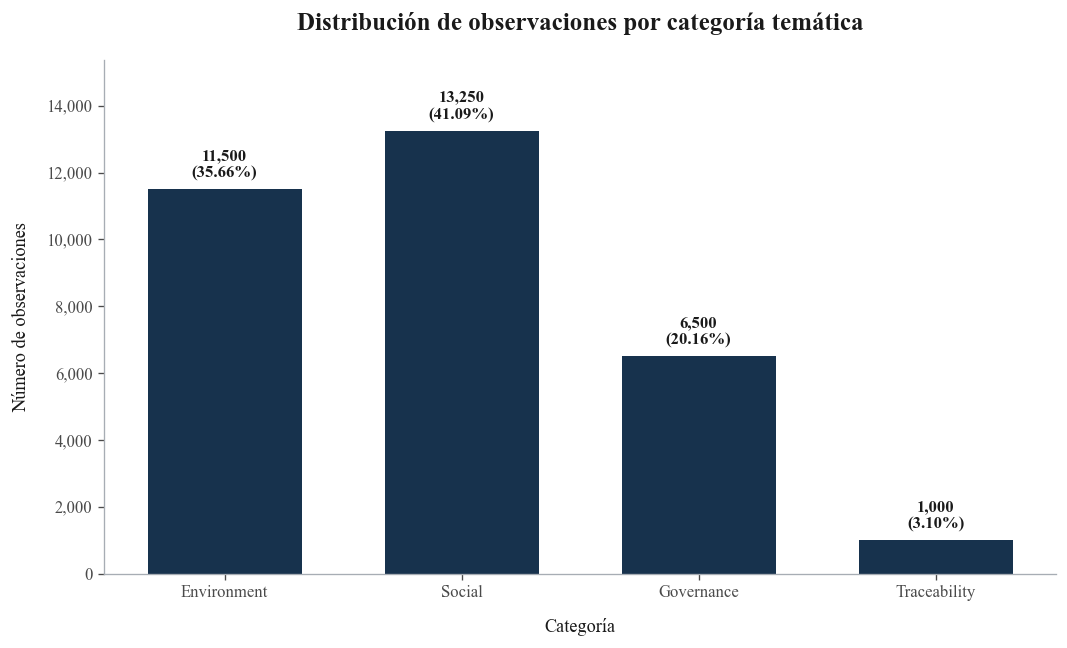

In [54]:
# Visualizamos la distribución de observaciones por categoría temática

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de barras
barras = ax.bar(
    resumen_categorias["Categoria"],
    resumen_categorias["Observaciones"],
    color=AZUL_MARINO,
    width=0.65
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de observaciones por categoría temática",
    pad=18
)

ax.set_xlabel("Categoría", labelpad=10)
ax.set_ylabel("Número de observaciones", labelpad=10)

# Aplicamos separadores de miles al eje vertical
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el número de observaciones y el porcentaje
# correspondiente sobre cada barra
for barra, observaciones, porcentaje in zip(
    barras,
    resumen_categorias["Observaciones"],
    resumen_categorias["Porcentaje"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 250,
        f"{observaciones:,.0f}\n({porcentaje:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio superior para las etiquetas
ax.set_ylim(
    0,
    resumen_categorias["Observaciones"].max() * 1.16
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(fig, "distribucion_observaciones_categoria")

plt.show()


La distribución de las observaciones evidencia que la base de datos no se encuentra equilibrada entre categorías temáticas. En conjunto, **Environment** y **Social** concentran el **76.75%** de las observaciones, mientras que **Governance** y **Traceability** representan el **23.25%** restante. Esta composición indica que la información disponible en el *Fashion Transparency Index 2023* se encuentra orientada principalmente hacia indicadores ambientales y sociales, aspecto que debe considerarse al interpretar los resultados obtenidos en las etapas posteriores del análisis exploratorio.

### Distribución de indicadores por categoría temática

Además de analizar la distribución de las observaciones, resulta importante conocer cómo se distribuyen los indicadores entre las distintas categorías temáticas. Este análisis permite identificar el peso de cada dimensión dentro de la estructura del índice, independientemente del número de observaciones registradas por empresa.

In [55]:
# Calculamos el número de indicadores por categoría temática

indicadores_categoria = (
    base[["Metric", "Categoria"]]
    .drop_duplicates()
    .groupby("Categoria")
    .size()
    .reindex(orden, fill_value=0)
    .reset_index(name="Indicadores")
)

# Calculamos el porcentaje de indicadores por categoría
indicadores_categoria["Porcentaje"] = (
    indicadores_categoria["Indicadores"]
    / indicadores_categoria["Indicadores"].sum()
    * 100
).round(2)

# Mostramos el resumen
display(indicadores_categoria)

,Categoria,Indicadores,Porcentaje
0,Environment,46,35.660
1,Social,53,41.090
2,Governance,26,20.160
3,Traceability,4,3.100


Se presenta una representación gráfica de la distribución de los indicadores que conforman el *Fashion Transparency Index 2023*.

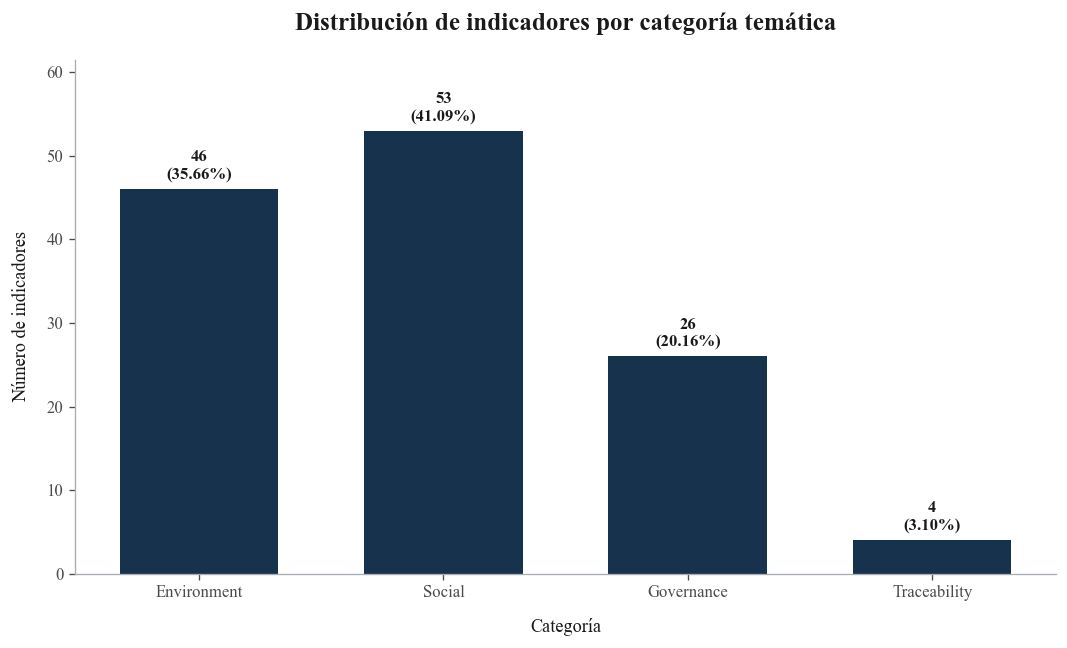

In [56]:
# Visualizamos la distribución de indicadores por categoría temática

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de barras
barras = ax.bar(
    indicadores_categoria["Categoria"],
    indicadores_categoria["Indicadores"],
    color=AZUL_MARINO,
    width=0.65
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de indicadores por categoría temática",
    pad=18
)

ax.set_xlabel("Categoría", labelpad=10)
ax.set_ylabel("Número de indicadores", labelpad=10)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el número de indicadores y el porcentaje correspondiente
for barra, indicadores, porcentaje in zip(
    barras,
    indicadores_categoria["Indicadores"],
    indicadores_categoria["Porcentaje"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.8,
        f"{indicadores}\n({porcentaje:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio superior para las etiquetas
ax.set_ylim(
    0,
    indicadores_categoria["Indicadores"].max() * 1.16
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(fig, "distribucion_indicadores_categoria")

plt.show()

La distribución de los indicadores confirma el mismo patrón observado previamente para las observaciones. Esto se debe a que cada indicador fue evaluado para el mismo conjunto de **250 empresas**, por lo que la distribución de las observaciones es directamente proporcional al número de indicadores por categoría. No obstante, este análisis permite identificar la estructura del *Fashion Transparency Index 2023*, evidenciando que **Environment** y **Social** concentran **99 de los 129 indicadores analizados**, mientras que **Governance** y **Traceability** reúnen únicamente **30 indicadores**. Esta diferencia refleja una mayor representación de indicadores ambientales y sociales dentro de la clasificación temática utilizada en el proyecto, aspecto que será considerado durante el análisis de los resultados de esta sección.

## Indicadores binarios

### Nivel de divulgación de los indicadores

Una vez descrita la composición de la base de datos, se analiza el nivel de divulgación de los indicadores de transparencia.

In [57]:
# Cargamos la matriz empresa-indicador obtenida
# en el notebook anterior

matriz = pd.read_csv(
    ruta_datos / "matriz_empresas_clustering.csv"
)


# Separamos la información descriptiva de las variables
# numéricas utilizadas en el análisis
informacion_empresas = matriz[
    ["Company", "Pais_sede"]
].copy()

matriz_indicadores = matriz.drop(
    columns=["Company", "Pais_sede"]
)


# Calculamos el porcentaje de divulgación por indicador
divulgacion = (
    matriz_indicadores
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

divulgacion.columns = [
    "Indicador",
    "Porcentaje de divulgación"
]

In [58]:
# Calculamos estadísticas descriptivas de las tasas de divulgación

estadisticas_divulgacion = (
    divulgacion["Porcentaje de divulgación"]
    .describe()
    .to_frame(name="Valor")
)

# Mostramos el resumen estadístico
display(estadisticas_divulgacion)

,Valor
count,109.000
mean,25.372
std,19.980
min,0.800
25%,7.200
50%,22.400
75%,37.600
max,75.200


A continuación un histograma que muestra la frecuencia de los porcentajes de divulgación observados.

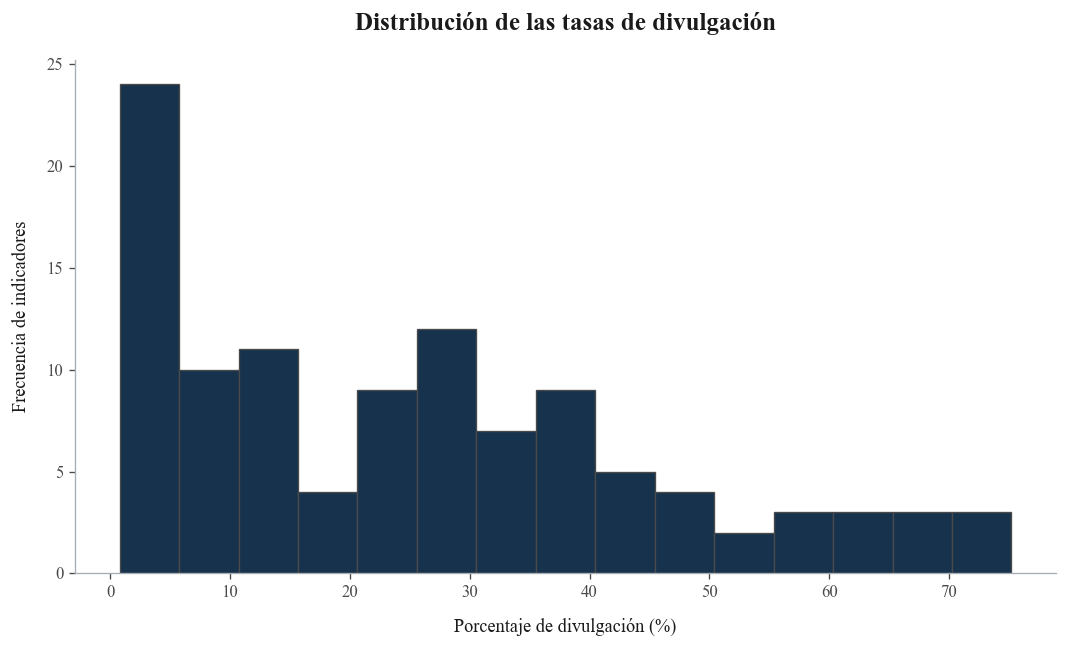

In [59]:
# Visualizamos la distribución de las tasas de divulgación

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos el histograma
ax.hist(
    divulgacion["Porcentaje de divulgación"],
    bins=15,
    color=AZUL_MARINO,
    edgecolor=GRIS_OSCURO,
    linewidth=0.8
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de las tasas de divulgación",
    pad=18
)

ax.set_xlabel("Porcentaje de divulgación (%)", labelpad=10)
ax.set_ylabel("Frecuencia de indicadores", labelpad=10)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(fig, "distribucion_tasas_divulgacion")

plt.show()

Las tasas de divulgación presentan una elevada variabilidad entre indicadores, con valores que oscilan entre **0.8%** y **75.2%**, lo que representa un rango de **74.4 puntos porcentuales**. En promedio, los indicadores son divulgados por el **25.37%** de las empresas. Además, la mediana de **22.40%** indica que la mitad de los indicadores presenta un nivel de divulgación igual o inferior a ese porcentaje. Asimismo, el histograma muestra una concentración importante de indicadores en los niveles bajos de divulgación, junto con una menor presencia de indicadores conforme se alcanzan porcentajes más elevados. 

En conjunto, estos resultados evidencian que la transparencia corporativa no se distribuye de manera uniforme entre los indicadores, sino que existe un número reducido de prácticas ampliamente divulgadas y una proporción considerable de indicadores con bajos niveles de reporte.

### Indicadores con mayor nivel de divulgación

Una vez caracterizada la distribución general de las tasas de divulgación, se identifican los indicadores con mayor porcentaje de reporte por parte de las empresas. 

In [60]:
# Identificamos los diez indicadores con mayor nivel de divulgación

top_10_divulgacion = divulgacion.head(10)

# Mostramos el resultado
display(top_10_divulgacion)

,Indicador,Porcentaje de divulgación
0,Fashion Revolution+Supply Chain Policies Align with International Standards,75.200
1,Fashion Revolution+Plan for Improving Environmental Impacts,71.600
2,Fashion Revolution+Supply Chain Policies Are Contractual,71.200
3,Fashion Revolution+Describes Human Rights Due Diligence Process,67.600
4,Fashion Revolution+Grievance Mechanism - Direct Employees,67.200
5,Fashion Revolution+Implementation of Board Level Accountability Described,66.000
6,Fashion Revolution+New Production Facility Criteria,63.600
7,Fashion Revolution+Reports on Efforts to Improve Environmental Impacts,61.200
8,Fashion Revolution+Grievance Mechanism - Supply Chain Workers,61.200
9,"Fashion Revolution+Discloses Content of Scope 1, 2 and 3 Emissions",59.600


In [61]:
# Reconstruimos la tabla de divulgación con los nombres originales

divulgacion = (
    matriz_indicadores
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

divulgacion.columns = [
    "Indicador_original",
    "Porcentaje de divulgación"
]


# Recuperamos la categoría temática correspondiente
# a cada indicador
categorias = (
    base[
        ["Metric", "Categoria"]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "Metric": "Indicador_original"
        }
    )
)


# Incorporamos la categoría temática utilizando
# los nombres originales de los indicadores
divulgacion = divulgacion.merge(
    categorias,
    on="Indicador_original",
    how="left",
    validate="one_to_one"
)


# Creamos una versión limpia del nombre para tablas
# y visualizaciones
divulgacion["Indicador"] = (
    divulgacion["Indicador_original"]
    .str.replace(
        "Fashion Revolution+",
        "",
        regex=False
    )
)


# Reordenamos las columnas
divulgacion = divulgacion[
    [
        "Categoria",
        "Indicador",
        "Porcentaje de divulgación"
    ]
]


# Verificamos que no existan categorías faltantes
print(
    "Categorías faltantes:",
    divulgacion["Categoria"].isna().sum()
)


# Seleccionamos los diez indicadores con mayor divulgación
top_10_divulgacion = divulgacion.head(10).copy()

display(top_10_divulgacion)

Categorías faltantes: 0


,Categoria,Indicador,Porcentaje de divulgación
0,Governance,Supply Chain Policies Align with International Standards,75.200
1,Environment,Plan for Improving Environmental Impacts,71.600
2,Governance,Supply Chain Policies Are Contractual,71.200
3,Social,Describes Human Rights Due Diligence Process,67.600
4,Social,Grievance Mechanism - Direct Employees,67.200
5,Governance,Implementation of Board Level Accountability Described,66.000
6,Social,New Production Facility Criteria,63.600
7,Environment,Reports on Efforts to Improve Environmental Impacts,61.200
8,Social,Grievance Mechanism - Supply Chain Workers,61.200
9,Environment,"Discloses Content of Scope 1, 2 and 3 Emissions",59.600


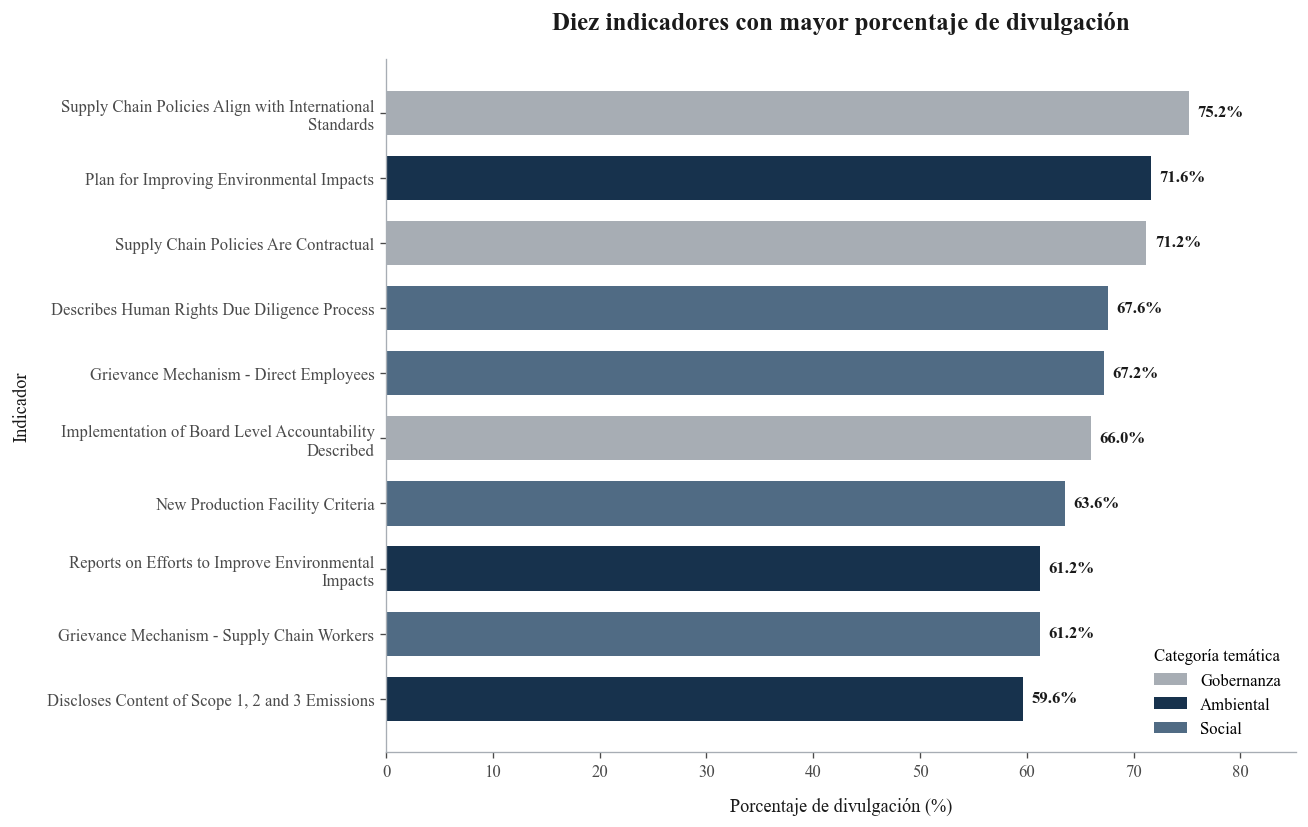

In [62]:
# Visualizamos los diez indicadores con mayor porcentaje de divulgación

import textwrap
from matplotlib.patches import Patch

# Definimos los colores de las categorías temáticas
COLOR_CATEGORIAS = {
    "Environment": AZUL_MARINO,
    "Social": AZUL_SECUNDARIO,
    "Governance": GRIS_MEDIO,
    "Traceability": GRIS_CLARO
}

# Traducimos las categorías únicamente para fines de presentación
CATEGORIAS_ES = {
    "Environment": "Ambiental",
    "Social": "Social",
    "Governance": "Gobernanza",
    "Traceability": "Trazabilidad"
}

# Creamos una copia para preparar las etiquetas de la figura
top_10_grafica = top_10_divulgacion.copy()

# Dividimos automáticamente los nombres largos en varias líneas
top_10_grafica["Indicador_visual"] = (
    top_10_grafica["Indicador"]
    .apply(lambda texto: textwrap.fill(texto, width=48))
)

# Asignamos un color según la categoría temática
colores = (
    top_10_grafica["Categoria"]
    .map(COLOR_CATEGORIAS)
)

# Construimos la figura
fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    top_10_grafica["Indicador_visual"],
    top_10_grafica["Porcentaje de divulgación"],
    color=colores,
    height=0.68
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Diez indicadores con mayor porcentaje de divulgación",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de divulgación (%)",
    labelpad=10
)

ax.set_ylabel(
    "Indicador",
    labelpad=10
)

# Mostramos el indicador con mayor divulgación en la parte superior
ax.invert_yaxis()

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje al final de cada barra
for barra, valor in zip(
    barras,
    top_10_grafica["Porcentaje de divulgación"]
):
    ax.text(
        valor + 0.8,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Construimos la leyenda con los nombres de las categorías en español
categorias_presentes = (
    top_10_grafica["Categoria"]
    .drop_duplicates()
)

elementos_leyenda = [
    Patch(
        facecolor=COLOR_CATEGORIAS[categoria],
        label=CATEGORIAS_ES[categoria]
    )
    for categoria in categorias_presentes
]

ax.legend(
    handles=elementos_leyenda,
    title="Categoría temática",
    frameon=False,
    loc="lower right"
)

# Dejamos espacio para mostrar los porcentajes
ax.set_xlim(
    0,
    top_10_grafica["Porcentaje de divulgación"].max() + 10
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura en alta resolución
guardar_figura(
    fig,
    "top_10_indicadores_divulgacion"
)

plt.show()

Los indicadores con mayor porcentaje de divulgación presentan niveles de reporte que oscilan entre **59.6%** y **75.2%** de las empresas evaluadas. El indicador con mayor divulgación corresponde a **Supply Chain Policies Align with International Standards** (*informa si las políticas para la cadena de suministro están alineadas con estándares internacionales*), reportado por el **75.2%** de las empresas, mientras que el décimo lugar, **Discloses Content of Scope 1, 2 and 3 Emissions** (*divulga el contenido de las emisiones de alcance 1, 2 y 3*), alcanza un **59.6%**. La diferencia entre ambos es de **15.6 puntos porcentuales**, lo que indica que incluso entre las prácticas más ampliamente divulgadas existe variabilidad en los niveles de divulgación.

En el caso de **Supply Chain Policies Align with International Standards** (*informa si las políticas para la cadena de suministro están alineadas con estándares internacionales*), su nivel de divulgación puede relacionarse con la existencia de referencias institucionales ampliamente reconocidas. La Declaración Tripartita de la OIT (Organización Internacional del Trabajo) proporciona orientación directa a las empresas sobre prácticas laborales responsables basada en las normas internacionales del trabajo, mientras que la Guía de la OCDE (Organización para la Cooperación y el Desarrollo Económicos) para el sector textil establece un marco común de debida diligencia (identificación y gestión de riesgos) alineado con instrumentos de la OIT, las Naciones Unidas y la propia OCDE. Estos instrumentos funcionan principalmente como estándares y orientaciones internacionales, no como una obligación legal universal para todas las empresas, pero proporcionan criterios concretos que pueden incorporarse a las políticas corporativas (OIT, 2023; OCDE, 2018).

El indicador **Plan for Improving Environmental Impacts** (*cuenta con un plan para mejorar los impactos ambientales*) fue divulgado por el **71.6%** de las empresas. En la Unión Europea, la Directiva 2014/95/UE exigía a determinadas grandes empresas divulgar sus políticas, resultados, riesgos y procesos de debida diligencia relacionados, entre otros aspectos, con cuestiones ambientales. Aunque esta obligación no alcanzaba a todas las empresas evaluadas, sí estableció para las compañías incluidas un requerimiento concreto de documentar cómo gestionaban sus impactos ambientales (Parlamento Europeo y Consejo de la Unión Europea, 2014).

Para **Supply Chain Policies Are Contractual** (*las políticas de la cadena de suministro forman parte de los contratos con proveedores*), reportado por el **71.2%**, existe una relación particularmente directa con algunas obligaciones regulatorias. La Ley alemana de Debida Diligencia en las Cadenas de Suministro establece, para las empresas sujetas a esta ley, la obtención de garantías contractuales de los proveedores directos respecto del cumplimiento de expectativas ambientales y de derechos humanos, así como la incorporación de mecanismos contractuales de control. Por lo tanto, en ciertos casos la inclusión de estas políticas en los contratos no responde únicamente a una práctica voluntaria, sino a un requerimiento legal aplicable a empresas específicas (República Federal de Alemania, 2021, § 6).

El indicador **Describes Human Rights Due Diligence Process** (*describe su proceso de debida diligencia en derechos humanos*) alcanzó un **67.6%**. Los Principios Rectores de las Naciones Unidas establecen la debida diligencia como un proceso para identificar, prevenir, mitigar y explicar cómo las empresas abordan sus impactos sobre los derechos humanos. Este proceso también fue desarrollado específicamente para la industria de la moda por la OCDE y, para determinadas grandes empresas europeas, la Directiva 2014/95/UE exigía divulgar los procesos de debida diligencia implementados, incluso en las cadenas de suministro y subcontratación cuando fuera pertinente (ACNUDH, 2011; OCDE, 2018; Parlamento Europeo y Consejo de la Unión Europea, 2014).

En **Grievance Mechanism – Direct Employees** (*cuenta con un mecanismo de queja para sus empleados directos*), divulgado por el **67.2%**, también existe un marco institucional definido. Los Principios Rectores de las Naciones Unidas promueven mecanismos operacionales de reclamación que permitan atender de manera temprana los impactos relacionados con los derechos humanos. Además, la legislación alemana exige a las empresas incluidas establecer un procedimiento interno de queja que permita reportar riesgos o incumplimientos ambientales y de derechos humanos producidos dentro de sus propias operaciones o por proveedores directos (ACNUDH, 2011; República Federal de Alemania, 2021, § 8).

El indicador **Implementation of Board Level Accountability Described** (*describe cómo se implementa la responsabilidad en el nivel del consejo de administración*) fue divulgado por el **66.0%**. En este caso destaca la influencia de estándares de reporte corporativo. GRI (Iniciativa de Reporte Global) 2 solicita a las organizaciones que reportan bajo sus estándares describir la función del máximo órgano de gobierno en la supervisión de los impactos ambientales, sociales y de derechos humanos, así como su participación en la revisión y aprobación de la información de sostenibilidad. GRI constituye un estándar de reporte y no una ley de aplicación universal, pero proporciona una estructura concreta para divulgar la responsabilidad del consejo (Global Reporting Initiative, 2021).

Para **New Production Facility Criteria** (*divulga los criterios utilizados para seleccionar nuevas instalaciones de producción*), con **63.6%**, la Ley alemana de Debida Diligencia establece que las empresas comprendidas deben considerar las expectativas ambientales y de derechos humanos al seleccionar proveedores directos. De manera complementaria, la guía sectorial de la OCDE promueve la incorporación de criterios de conducta empresarial responsable y de riesgo en las decisiones de abastecimiento y en las relaciones con proveedores. Estos marcos proporcionan una motivación institucional para documentar los criterios empleados al incorporar nuevas instalaciones a la cadena de suministro (República Federal de Alemania, 2021, § 6; OCDE, 2018).

El indicador **Reports on Efforts to Improve Environmental Impacts** (*informa sobre los esfuerzos realizados para mejorar sus impactos ambientales*) fue divulgado por el **61.2%**. La Directiva 2014/95/UE requería que las empresas incluidas informaran sobre sus políticas ambientales y los resultados obtenidos, mientras que GRI 3 solicita describir las acciones adoptadas para gestionar los impactos y evaluar la eficacia de dichas acciones. En este caso convergen una obligación de divulgación aplicable a determinadas compañías europeas y un estándar voluntario utilizado para estructurar la información sobre las medidas ambientales implementadas (Parlamento Europeo y Consejo de la Unión Europea, 2014; Global Reporting Initiative, 2021).

En **Grievance Mechanism – Supply Chain Workers** (*cuenta con un mecanismo de queja para los trabajadores de la cadena de suministro*), también divulgado por el **61.2%**, los Principios Rectores de las Naciones Unidas y la Guía de la OCDE promueven mecanismos que permitan a las personas afectadas comunicar impactos y acceder a medidas de reparación. La legislación alemana reforzó esta expectativa al exigir un procedimiento que permita reportar riesgos o incumplimientos originados tanto en las operaciones propias como en las de los proveedores directos. Por ello, para algunas empresas este mecanismo forma parte de obligaciones legales de debida diligencia, mientras que para otras continúa siendo una expectativa derivada de estándares internacionales (ACNUDH, 2011; OCDE, 2018; República Federal de Alemania, 2021, § 8).

Finalmente, **Discloses Content of Scope 1, 2 and 3 Emissions** (*divulga el contenido de las emisiones de alcance 1, 2 y 3*) alcanzó un **59.6%**. El GHG Protocol estableció metodologías estandarizadas para medir y reportar las emisiones directas, las emisiones asociadas con la energía adquirida y las emisiones indirectas de la cadena de valor. En particular, su estándar de alcance 3 proporciona requisitos y orientación para preparar y divulgar públicamente un inventario de emisiones de la cadena de valor. El GHG Protocol no constituye por sí mismo una obligación legal universal, pero ofrece una metodología internacional común que facilita que las empresas midan y reporten esta información de manera comparable (GHG Protocol, 2004, 2011).

En este contexto, se observa que los diez indicadores pertenecen exclusivamente a las categorías **Gobernanza**, **Ambiental** y **Social**. En particular, **cuatro** corresponden a la dimensión Social, **tres** a Gobernanza y **tres** a Ambiental, mientras que **ningún** indicador de Trazabilidad aparece entre los niveles más altos de divulgación. No obstante, la presencia de **cuatro indicadores sociales** entre los diez primeros no implica que la dimensión Social tenga el mayor nivel promedio de divulgación. Este resultado describe únicamente la composición de las diez posiciones más altas. Una categoría puede incluir algunos indicadores con porcentajes elevados y, al mismo tiempo, una cantidad considerable de indicadores con niveles bajos; por ello, la comparación general entre dimensiones deberá realizarse posteriormente considerando todos los indicadores que integran cada categoría.

En conjunto, estos resultados muestran que los indicadores con mayor nivel de divulgación se concentran principalmente en políticas corporativas, mecanismos de gobernanza, procesos de debida diligencia y acciones relacionadas con la gestión de impactos ambientales y sociales.



### Indicadores con menor nivel de divulgación

A continuación, se identifican los diez indicadores con menor porcentaje de divulgación dentro del Fashion Transparency Index 2023. Este análisis permite reconocer las prácticas sobre las cuales las empresas proporcionan información con menor frecuencia.

In [63]:
# Identificamos los diez indicadores con menor nivel de divulgación

bottom_10_divulgacion = divulgacion.tail(10).copy()

# Mostramos el resultado
display(bottom_10_divulgacion)

,Categoria,Indicador,Porcentaje de divulgación
99,Governance,Discloses Free on Board (FOB) Price Changes (COVID-19 Response),2.000
100,Social,Discloses Strategy to Achieving Living Wage,2.000
101,Social,Reports on Minimum Wage Paid for Daily / Piece Rate Workers,1.600
102,Environment,Discloses Percentage of Workers Paid By Piece Rate,1.600
103,Social,Discloses Progress toward the payment of a Living Wage to workers in the supply chain,1.600
104,Social,Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum,1.200
105,Social,Publishes Percentage or Number of Workers Earning a Living Wage,1.200
106,Governance,Discloses Policy on Up-Front Supplier Payments,0.800
107,Environment,Commitment to Degrowth,0.800
108,Governance,Publishes Standard Supplier Agreement Template,0.800


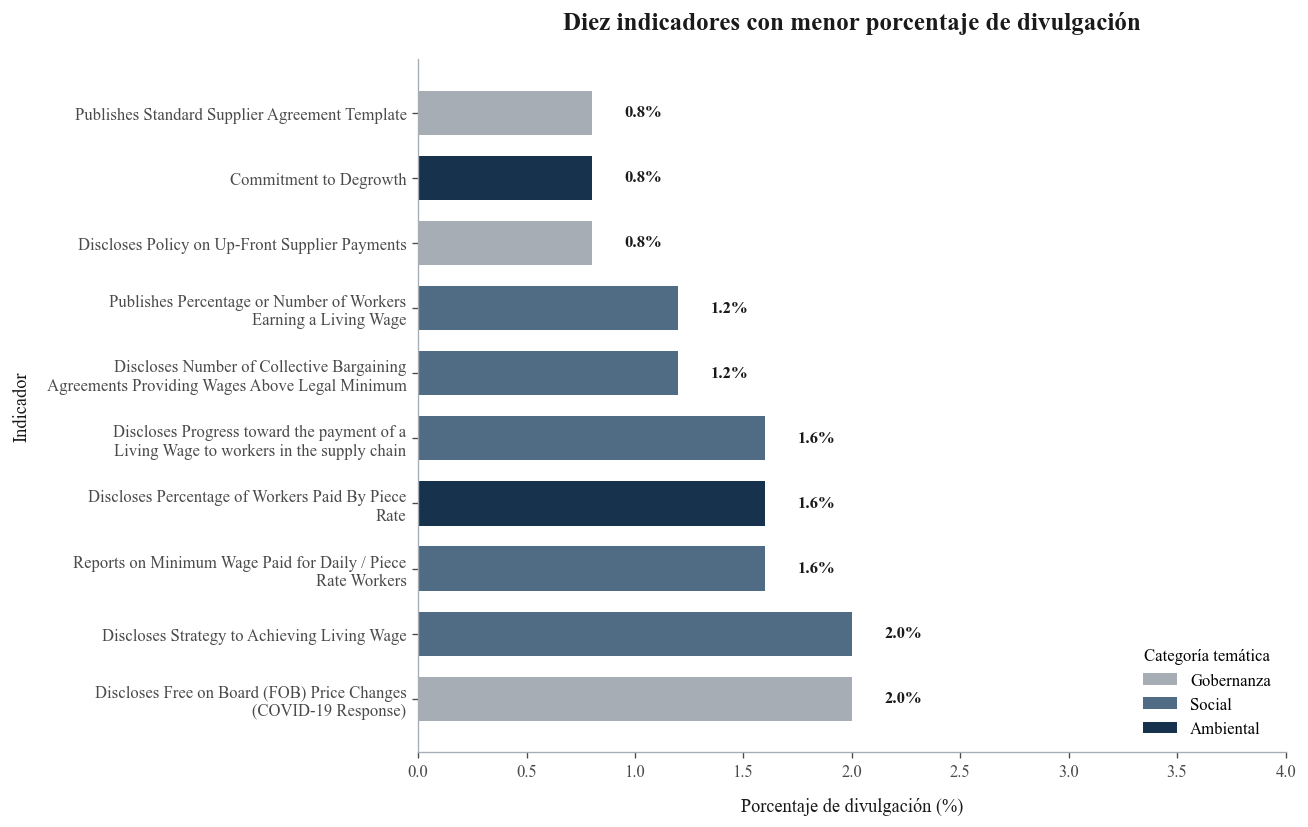

In [64]:
# Visualizamos los diez indicadores con menor porcentaje de divulgación

import textwrap
from matplotlib.patches import Patch

# Creamos una copia para preparar las etiquetas de la figura
bottom_10_grafica = bottom_10_divulgacion.copy()

# Dividimos automáticamente los nombres largos en varias líneas
bottom_10_grafica["Indicador_visual"] = (
    bottom_10_grafica["Indicador"]
    .apply(lambda texto: textwrap.fill(texto, width=48))
)

# Asignamos un color según la categoría temática
colores = (
    bottom_10_grafica["Categoria"]
    .map(COLOR_CATEGORIAS)
)

# Construimos la figura
fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    bottom_10_grafica["Indicador_visual"],
    bottom_10_grafica["Porcentaje de divulgación"],
    color=colores,
    height=0.68
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Diez indicadores con menor porcentaje de divulgación",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de divulgación (%)",
    labelpad=10
)

ax.set_ylabel(
    "Indicador",
    labelpad=10
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje al final de cada barra
for barra, valor in zip(
    barras,
    bottom_10_grafica["Porcentaje de divulgación"]
):
    ax.text(
        valor + 0.15,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Construimos la leyenda
categorias_presentes = (
    bottom_10_grafica["Categoria"]
    .drop_duplicates()
)

elementos_leyenda = [
    Patch(
        facecolor=COLOR_CATEGORIAS[categoria],
        label=CATEGORIAS_ES[categoria]
    )
    for categoria in categorias_presentes
]

ax.legend(
    handles=elementos_leyenda,
    title="Categoría temática",
    frameon=False,
    loc="lower right"
)

# Dejamos espacio para mostrar los porcentajes
ax.set_xlim(0, 4)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "bottom_10_indicadores_divulgacion"
)

plt.show()

Los indicadores con menor porcentaje de divulgación presentan niveles de reporte que oscilan entre **0.8%** y **2.0%** de las empresas evaluadas. El indicador con mayor divulgación dentro de este grupo corresponde a **Discloses Free on Board (FOB) Price Changes (COVID-19 Response)** (*divulga cambios en los precios Free on Board (FOB) como respuesta a la COVID-19*) y **Discloses Strategy to Achieving Living Wage** (*divulga la estrategia para lograr el pago de un salario digno*), ambos reportados por únicamente el **2.0%** de las empresas. En contraste, los indicadores **Discloses Policy on Up-Front Supplier Payments** (*divulga una política de pagos anticipados a proveedores*), **Commitment to Degrowth** (*compromiso con estrategias de decrecimiento para reducir el impacto ambiental*) y **Publishes Standard Supplier Agreement Template** (*publica un modelo estándar de contrato para proveedores*) son reportados por apenas el **0.8%** de las empresas. La diferencia entre el indicador con mayor y menor divulgación dentro de este grupo es de **1.2 puntos porcentuales**, lo que evidencia que todos estos indicadores presentan niveles de divulgación extremadamente bajos.

En **Publishes Standard Supplier Agreement Template** (*publica un modelo estándar de contrato para proveedores*), divulgado por el **0.8%** de las empresas, existen marcos que regulan o recomiendan el contenido de las relaciones contractuales con proveedores, pero no necesariamente su publicación. La Guía de la OCDE para el sector textil incorpora las cláusulas contractuales, los precios y las condiciones de compra dentro de las prácticas que deben considerarse en la debida diligencia, mientras que la Ley alemana de Debida Diligencia exige a las empresas bajo esta ley obtener garantías contractuales de sus proveedores directos sobre determinadas expectativas ambientales y de derechos humanos. Sin embargo, estos instrumentos no establecen una obligación general de publicar el modelo completo de contrato utilizado con los proveedores. Por ello, este indicador exige un nivel de transparencia adicional al simple uso de cláusulas contractuales (OCDE, 2018; República Federal de Alemania, 2021, § 6).

Para **Commitment to Degrowth** (*compromiso con estrategias de decrecimiento para reducir el impacto ambiental*), también con **0.8%**, no se identifica una obligación regulatoria general que exija a las empresas asumir o divulgar explícitamente un compromiso de decrecimiento. La Estrategia de la Unión Europea para la circularidad y sostenibilidad de los productos textiles reconoce el crecimiento de la producción y el consumo como un problema ambiental y plantea reducir los impactos mediante productos duraderos, reciclables, modelos circulares y medidas contra la moda rápida. Sin embargo, el marco se orienta hacia la circularidad y la reducción de impactos, no hacia una obligación empresarial de adoptar públicamente el decrecimiento como estrategia corporativa (Comisión Europea, 2022).

En **Discloses Policy on Up-Front Supplier Payments** (*divulga una política de pagos anticipados a proveedores*), reportado por el **0.8%**, la OCDE reconoce que las prácticas de compra de las marcas pueden afectar directamente a las condiciones laborales dentro de las fábricas proveedoras. Su guía recomienda revisar aspectos como precios, modificaciones de pedidos, plazos y otras prácticas comerciales que puedan generar impactos negativos. No obstante, estas recomendaciones no establecen una obligación general de realizar pagos anticipados a los proveedores ni de publicar una política específica sobre qué porcentaje del pedido se paga antes de iniciar la producción, por lo que este indicador se encuentra principalmente dentro del terreno de las prácticas responsables de compra y la transparencia voluntaria (OCDE, 2018, 2020).

El indicador **Publishes Percentage or Number of Workers Earning a Living Wage** (*publica el porcentaje o número de trabajadores que reciben un salario digno*) alcanzó únicamente **1.2%**. La Declaración Tripartita de la OIT recomienda que las empresas multinacionales proporcionen salarios que permitan, como mínimo, satisfacer las necesidades básicas de los trabajadores y sus familias. Sin embargo, esta disposición constituye orientación dirigida a las empresas y no una obligación legal universal de pagar o publicar el número de trabajadores que reciben un salario digno. Por otra parte, el Convenio 131 de la OIT obliga a los Estados que lo ratifican a establecer sistemas de **salario mínimo**, pero no establece una obligación empresarial general de divulgar cuántos trabajadores reciben un salario digno, que constituye un concepto distinto al mínimo legal (OIT, 1970, 2023).

En **Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum** (*divulga el número de convenios colectivos que establecen salarios superiores al mínimo legal*), divulgado por el **1.2%**, sí existen normas internacionales relacionadas con la negociación colectiva. El Convenio 98 de la OIT establece que los Estados que lo ratifican deben adoptar medidas para promover la negociación voluntaria entre empleadores y trabajadores, mientras que el Convenio 131 reconoce que los salarios mínimos tienen fuerza legal. Sin embargo, estos convenios no obligan de manera general a las empresas a publicar cuántos acuerdos colectivos establecen salarios superiores al mínimo legal. Por lo tanto, el indicador mide la divulgación de un resultado específico de la negociación colectiva que va más allá de la obligación de respetar este derecho (OIT, 1949, 1970).

El indicador **Discloses Progress toward the Payment of a Living Wage to Workers in the Supply Chain** (*divulga el progreso hacia el pago de un salario digno a los trabajadores de la cadena de suministro*) fue reportado por el **1.6%**. Aunque la OIT proporciona orientación para que las empresas procuren salarios suficientes para cubrir las necesidades básicas de los trabajadores y sus familias, no establece una obligación universal de publicar avances anuales hacia un salario digno (OIT, 2023). Incluso la Directiva 2014/95/UE, que sí exigía a determinadas grandes empresas divulgar información sobre cuestiones sociales, laborales, derechos humanos, políticas y resultados, no establecía específicamente que debieran reportar el avance hacia el pago de salarios dignos en su cadena de suministro. Esto muestra que existían obligaciones de divulgación social, pero con un nivel de detalle menor al solicitado por este indicador (Parlamento Europeo y Consejo de la Unión Europea, 2014; OIT, 2023).

Para **Discloses Percentage of Workers Paid By Piece Rate** (*divulga el porcentaje de trabajadores pagados por pieza producida*), con **1.6%**, la OIT reconoce expresamente el pago por pieza como una modalidad utilizada en industrias como la textil, la confección y el calzado. Sus estándares señalan que la forma de calcular el salario no elimina la protección salarial y que los trabajadores pagados por pieza deben quedar protegidos por los sistemas de salario mínimo aplicables. Sin embargo, estas normas regulan la protección del salario y no establecen una obligación general para las marcas de publicar qué porcentaje de trabajadores de su cadena recibe este tipo de remuneración (OIT, 1970, 2015).

De manera relacionada, **Reports on Minimum Wage Paid for Daily / Piece Rate Workers** (*informa sobre el salario mínimo pagado a trabajadores remunerados por día o por pieza*) también presenta un **1.6%** de divulgación. El Convenio 131 de la OIT establece que los Estados que lo ratifican deben crear sistemas de salarios mínimos y que dichos salarios deben tener fuerza de ley. La OIT también señala que, cuando existen pagos por pieza, debe garantizarse que la remuneración respete la protección del salario mínimo correspondiente. Sin embargo, el cumplimiento de un salario mínimo y la **divulgación pública por parte de una marca de cuánto reciben estos trabajadores dentro de su cadena de suministro son obligaciones diferentes**; los instrumentos internacionales revisados no establecen este último requisito de forma universal (OIT, 1970, 2015).

En **Discloses Strategy to Achieving Living Wage** (*divulga la estrategia para lograr el pago de un salario digno*), reportado por el **2.0%**, nuevamente existe una diferencia entre la existencia de estándares laborales y una obligación específica de transparencia. La Declaración Tripartita de la OIT orienta a las empresas multinacionales hacia salarios capaces de satisfacer las necesidades básicas de los trabajadores y sus familias, mientras que la Guía de la OCDE incorpora los salarios y las condiciones laborales dentro de los riesgos que deben considerarse en la debida diligencia de la cadena de suministro. Sin embargo, estos marcos no obligan universalmente a las empresas a publicar una estrategia con objetivos y acciones específicas para alcanzar un salario digno. En este caso, la divulgación solicitada por el indicador supera lo exigido de manera general por estos instrumentos (OIT, 2023; OCDE, 2018).

Finalmente, **Discloses Free on Board (FOB) Price Changes (COVID-19 Response)** (*divulga cambios en los precios Free on Board [FOB] como respuesta a la COVID-19*), con **2.0%**, corresponde a una práctica muy específica de transparencia sobre las relaciones comerciales con proveedores. Durante la pandemia, la OCDE señaló que las empresas debían considerar sus prácticas de compra dentro de la debida diligencia y recomendó vigilar aspectos como los precios y los cambios realizados a los pedidos después de haber sido colocados, debido a sus posibles efectos sobre proveedores y trabajadores. Sin embargo, esta orientación no estableció una obligación legal general de publicar cambios en los precios FOB como consecuencia de la COVID-19. Por ello, este indicador evalúa una práctica de transparencia comercial mucho más específica que los requerimientos generales de debida diligencia (OCDE, 2020).

Asimismo, se observa que **cinco** de los diez indicadores pertenecen a la categoría **Social**, **tres** a **Gobernanza** y **dos** a **Ambiental**, mientras que nuevamente no aparece ningún indicador de **Trazabilidad**. Destaca que la mayoría de estos indicadores está relacionada con **salarios dignos, negociación colectiva, condiciones de pago a proveedores y prácticas laborales**, temas que requieren un mayor nivel de transparencia sobre la relación de las empresas con sus trabajadores y su cadena de suministro. En conjunto, estos resultados sugieren que, aunque algunas empresas divulgan ampliamente sus políticas generales de sostenibilidad y gobernanza, existe una marcada resistencia a reportar información específica sobre condiciones laborales, remuneración y mecanismos contractuales, lo que constituye una de las principales brechas de transparencia observadas en el *Fashion Transparency Index 2023*.

### Resumen de los indicadores con mayor y menor divulgación según los requerimientos de reporte

A partir de la revisión institucional y regulatoria realizada para los diez indicadores con mayor y menor nivel de divulgación, se clasificó la evidencia encontrada según si existe una **obligación directa de reportar la información**, una **recomendación o estándar de reporte**, o si únicamente se identificaron normas relacionadas con el cumplimiento de la práctica, pero **sin un requerimiento específico de divulgación pública**.

In [65]:
# Resumen de los indicadores con mayor y menor divulgación
# según los requerimientos de reporte identificados

resumen_reporte = pd.DataFrame([
    ["Alto", "Supply Chain Policies Align with International Standards", "75.2%", "Nada específico",
     "OIT/OCDE orientan sobre estándares y políticas, pero nuestro texto no identifica obligación ni recomendación explícita de publicar esa alineación."],

    ["Alto", "Plan for Improving Environmental Impacts", "71.6%", "Obligación",
     "Directiva 2014/95/UE exigía a determinadas empresas divulgar políticas, resultados, riesgos y debida diligencia ambiental."],

    ["Alto", "Supply Chain Policies Are Contractual", "71.2%", "Nada específico",
     "Ley alemana obliga a incorporar garantías contractuales, pero no identificamos obligación de publicar que esas políticas sean contractuales."],

    ["Alto", "Describes Human Rights Due Diligence Process", "67.6%", "Obligación",
     "Directiva 2014/95/UE exigía a determinadas empresas divulgar sus procesos de debida diligencia."],

    ["Alto", "Grievance Mechanism – Direct Employees", "67.2%", "Nada específico",
     "ONU promueve y Alemania exige establecer el mecanismo, pero nuestro texto no señala obligación de hacerlo público."],

    ["Alto", "Implementation of Board Level Accountability Described", "66.0%", "Recomendación/estándar de reporte",
     "GRI 2 solicita describir públicamente la función del máximo órgano de gobierno a quienes reportan bajo GRI."],

    ["Alto", "New Production Facility Criteria", "63.6%", "Nada específico",
     "Alemania exige considerar ciertos criterios y OCDE los promueve, pero no identificamos obligación de divulgarlos."],

    ["Alto", "Reports on Efforts to Improve Environmental Impacts", "61.2%", "Obligación",
     "Directiva 2014/95/UE exigía divulgar políticas y resultados ambientales; GRI además recomienda reportar acciones y eficacia."],

    ["Alto", "Grievance Mechanism – Supply Chain Workers", "61.2%", "Nada específico",
     "Se promueve/exige la existencia del mecanismo, pero no encontramos en nuestro texto obligación de publicar su existencia o funcionamiento."],

    ["Alto", "Discloses Content of Scope 1, 2 and 3 Emissions", "59.6%", "Recomendación/estándar de reporte",
     "GHG Protocol proporciona metodología y orientación específica para preparar y divulgar públicamente inventarios de emisiones."],

    ["Bajo", "Publishes Standard Supplier Agreement Template", "0.8%", "Nada específico",
     "Hay normas sobre relaciones contractuales, pero no obligación general de publicar el contrato."],

    ["Bajo", "Commitment to Degrowth", "0.8%", "Nada específico",
     "No encontramos obligación ni recomendación específica de divulgar un compromiso de decrecimiento."],

    ["Bajo", "Discloses Policy on Up-Front Supplier Payments", "0.8%", "Nada específico",
     "OCDE recomienda revisar prácticas de compra, no publicar una política de pagos anticipados."],

    ["Bajo", "Publishes Percentage or Number of Workers Earning a Living Wage", "1.2%", "Nada específico",
     "OIT orienta sobre salarios, pero no obliga ni recomienda específicamente publicar cuántos trabajadores reciben salario digno."],

    ["Bajo", "Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum", "1.2%", "Nada específico",
     "OIT protege/promueve negociación colectiva y salario mínimo, pero no exige divulgar este resultado."],

    ["Bajo", "Discloses Progress toward the Payment of a Living Wage to Workers in the Supply Chain", "1.6%", "Nada específico",
     "Existía reporte social general, pero no obligación específica de publicar avances hacia salario digno."],

    ["Bajo", "Discloses Percentage of Workers Paid By Piece Rate", "1.6%", "Nada específico",
     "Hay protección para esta modalidad salarial, pero no obligación de publicar qué porcentaje de trabajadores la utiliza."],

    ["Bajo", "Reports on Minimum Wage Paid for Daily / Piece Rate Workers", "1.6%", "Nada específico",
     "Se obliga a respetar salarios mínimos, pero no a publicar esta información específica."],

    ["Bajo", "Discloses Strategy to Achieving Living Wage", "2.0%", "Nada específico",
     "OIT/OCDE orientan sobre salarios y debida diligencia, pero no obligan a publicar una estrategia de salario digno."],

    ["Bajo", "Discloses Free on Board (FOB) Price Changes (COVID-19 Response)", "2.0%", "Nada específico",
     "OCDE recomendó vigilar prácticas de compra, pero no publicar cambios específicos en precios FOB."]
], columns=[
    "Grupo",
    "Indicador",
    "%",
    "¿Qué tenemos sobre reporte?",
    "Razón"
])

display(resumen_reporte)

,Grupo,Indicador,%,¿Qué tenemos sobre reporte?,Razón
0,Alto,Supply Chain Policies Align with International Standards,75.2%,Nada específico,"OIT/OCDE orientan sobre estándares y políticas, pero nuestro texto no identifica obligación ni recomendación explícita de publicar esa alineación."
1,Alto,Plan for Improving Environmental Impacts,71.6%,Obligación,"Directiva 2014/95/UE exigía a determinadas empresas divulgar políticas, resultados, riesgos y debida diligencia ambiental."
2,Alto,Supply Chain Policies Are Contractual,71.2%,Nada específico,"Ley alemana obliga a incorporar garantías contractuales, pero no identificamos obligación de publicar que esas políticas sean contractuales."
3,Alto,Describes Human Rights Due Diligence Process,67.6%,Obligación,Directiva 2014/95/UE exigía a determinadas empresas divulgar sus procesos de debida diligencia.
4,Alto,Grievance Mechanism – Direct Employees,67.2%,Nada específico,"ONU promueve y Alemania exige establecer el mecanismo, pero nuestro texto no señala obligación de hacerlo público."
5,Alto,Implementation of Board Level Accountability Described,66.0%,Recomendación/estándar de reporte,GRI 2 solicita describir públicamente la función del máximo órgano de gobierno a quienes reportan bajo GRI.
6,Alto,New Production Facility Criteria,63.6%,Nada específico,"Alemania exige considerar ciertos criterios y OCDE los promueve, pero no identificamos obligación de divulgarlos."
7,Alto,Reports on Efforts to Improve Environmental Impacts,61.2%,Obligación,Directiva 2014/95/UE exigía divulgar políticas y resultados ambientales; GRI además recomienda reportar acciones y eficacia.
8,Alto,Grievance Mechanism – Supply Chain Workers,61.2%,Nada específico,"Se promueve/exige la existencia del mecanismo, pero no encontramos en nuestro texto obligación de publicar su existencia o funcionamiento."
9,Alto,"Discloses Content of Scope 1, 2 and 3 Emissions",59.6%,Recomendación/estándar de reporte,GHG Protocol proporciona metodología y orientación específica para preparar y divulgar públicamente inventarios de emisiones.


La comparación muestra una diferencia clara entre ambos grupos. Entre los **diez indicadores con mayor divulgación**, se identificaron **tres** para los cuales existen obligaciones directas de reporte y **dos** respaldados por recomendaciones o estándares específicos de divulgación. En los cinco restantes existen regulaciones o marcos relacionados con la práctica evaluada, pero no se identificó un requerimiento específico de hacer pública esa información.

En contraste, entre los **diez indicadores con menor divulgación** no se identificaron obligaciones directas ni estándares específicos que exijan publicar la información con el nivel de detalle solicitado por estos indicadores. En varios casos existen normas sobre salarios, negociación colectiva, condiciones laborales o relaciones con proveedores, pero estas se concentran principalmente en el **cumplimiento de la práctica y no en su divulgación pública**. Este resultado aporta evidencia inicial de que la existencia de requerimientos específicos de transparencia podría estar relacionada con mayores niveles de divulgación.

### Nivel promedio de divulgación por categoría temática

A continuación, se calcula el porcentaje promedio de divulgación de los indicadores binarios pertenecientes a las categorías Ambiental, Social y Gobernanza. La categoría Trazabilidad no aparece en esta comparación porque sus indicadores no forman parte de la matriz binaria utilizada en esta sección.

In [66]:
# Calculamos el porcentaje promedio de divulgación por categoría temática

divulgacion_categoria = (
    divulgacion
    .groupby("Categoria", as_index=False)
    ["Porcentaje de divulgación"]
    .mean()
    .round(2)
    .sort_values(
        by="Porcentaje de divulgación",
        ascending=False
    )
    .reset_index(drop=True)
)

# Incorporamos los nombres de las categorías en español para su presentación
divulgacion_categoria["Categoria_es"] = (
    divulgacion_categoria["Categoria"]
    .map(CATEGORIAS_ES)
)

# Reordenamos las columnas
divulgacion_categoria = divulgacion_categoria[
    [
        "Categoria",
        "Categoria_es",
        "Porcentaje de divulgación"
    ]
]

# Mostramos el resultado
display(divulgacion_categoria)

,Categoria,Categoria_es,Porcentaje de divulgación
0,Governance,Gobernanza,30.420
1,Environment,Ambiental,25.940
2,Social,Social,22.780


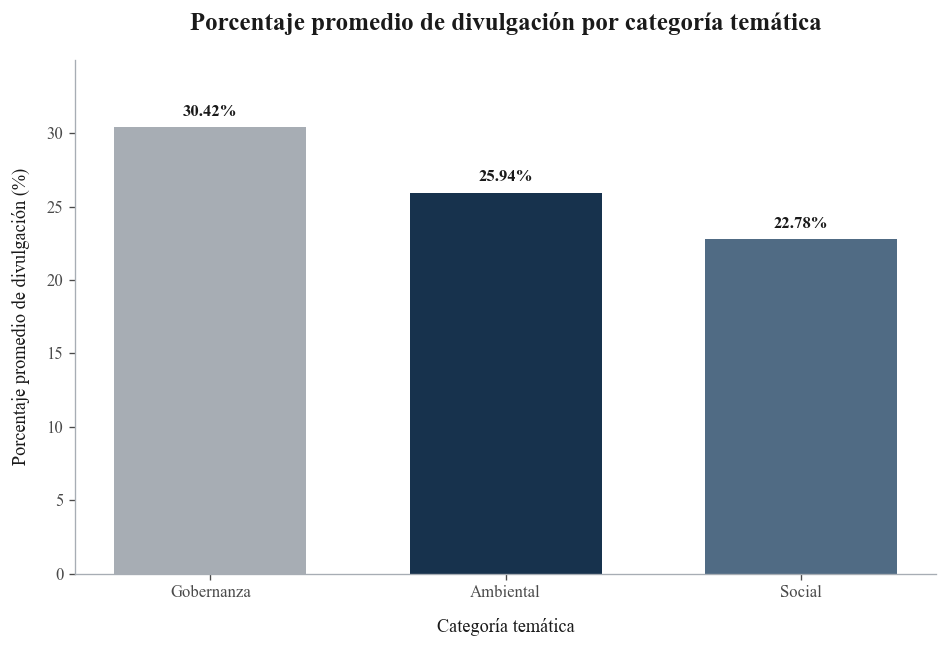

In [67]:
# Visualizamos el porcentaje promedio de divulgación por categoría temática

fig, ax = plt.subplots(figsize=(8, 5.5))

# Asignamos un color según la categoría temática
colores = (
    divulgacion_categoria["Categoria"]
    .map(COLOR_CATEGORIAS)
)

# Construimos la gráfica
barras = ax.bar(
    divulgacion_categoria["Categoria_es"],
    divulgacion_categoria["Porcentaje de divulgación"],
    color=colores,
    width=0.65
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Porcentaje promedio de divulgación por categoría temática",
    pad=18
)

ax.set_xlabel(
    "Categoría temática",
    labelpad=10
)

ax.set_ylabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje sobre cada barra
for barra, valor in zip(
    barras,
    divulgacion_categoria["Porcentaje de divulgación"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio para las etiquetas
ax.set_ylim(
    0,
    divulgacion_categoria["Porcentaje de divulgación"].max() * 1.15
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "promedio_divulgacion_categoria"
)

plt.show()

El nivel promedio de divulgación varía entre las distintas categorías temáticas del índice. La categoría **Gobernanza** presenta el mayor porcentaje promedio de divulgación (**30.42%**), seguida de **Ambiental** (**25.94%**) y **Social** (**22.78%**). En consecuencia, los indicadores de Gobernanza son divulgados, en promedio, **7.64 puntos porcentuales** más que los indicadores Sociales y **4.48 puntos porcentuales** más que los Ambientales. A partir de este resultado, se plantea como hipótesis que el mayor nivel de divulgación de Gobernanza puede estar relacionado con que este tipo de información cuenta con obligaciones y recomendaciones adicionales de transparencia corporativa y de mercados de capitales, particularmente para empresas que cotizan en bolsa, mientras que parte de las obligaciones sociales y ambientales se concentra en reportes más generales y no necesariamente en el nivel de detalle solicitado por algunos indicadores del *Fashion Transparency Index*.

Para **Gobernanza**, sí existen obligaciones directamente relacionadas con la publicación de información corporativa. En la Unión Europea, la Directiva 2013/34/UE exige a determinadas empresas cuyos valores cotizan en mercados regulados incluir una **declaración de gobernanza empresarial** dentro de su informe de gestión. Esta declaración debe informar, entre otros aspectos, sobre el código de gobernanza aplicado, las razones para apartarse de él, los sistemas de control interno y gestión de riesgos, los derechos de los accionistas y la composición y funcionamiento de los órganos de administración y sus comités (Parlamento Europeo y Consejo de la Unión Europea, 2013, art. 20). En Estados Unidos también existen requisitos específicos para las empresas sujetas a las reglas de la SEC, que incluyen divulgaciones sobre la estructura de liderazgo del consejo, su función en la supervisión de riesgos, las características de los directores y determinados aspectos de la remuneración y los comités corporativos (Securities and Exchange Commission, 2009). Estas obligaciones muestran que la transparencia sobre estructuras y responsabilidades de gobierno corporativo forma parte de los requerimientos habituales de los mercados de capitales para determinadas empresas.

Además de las obligaciones legales, los **Principios de Gobierno Corporativo del G20 y la OCDE** establecen como referencia internacional la divulgación oportuna y precisa sobre asuntos materiales, incluida su estructura de gobernanza. La OCDE señala específicamente que las prácticas y estructuras de gobierno corporativo deberían formar parte del reporte regular de las empresas y que, en muchas jurisdicciones, estos requerimientos se aplican mediante regulación, reglas de cotización o esquemas de *comply or explain* (*cumplir o explicar*). También recomienda divulgar información sobre la composición del consejo, remuneración de directivos, responsabilidades y políticas de gobernanza (OCDE, 2023). Por lo tanto, en esta dimensión convergen tanto **obligaciones de reporte** como **estándares internacionales de transparencia** dirigidos especialmente a empresas cotizadas.

Sin embargo, las dimensiones **Ambiental** y **Social** también cuentan con obligaciones directas de divulgación, por lo que no puede afirmarse que únicamente Gobernanza esté regulada. La Directiva 2014/95/UE exigía a determinadas grandes empresas de interés público con más de 500 empleados informar sobre cuestiones ambientales, sociales y laborales, derechos humanos y anticorrupción, incluyendo sus políticas, resultados, principales riesgos, procesos de debida diligencia e indicadores relevantes (Parlamento Europeo y Consejo de la Unión Europea, 2014). En materia ambiental, además, el Reglamento de Taxonomía de la Unión Europea exige a las empresas sujetas al reporte no financiero divulgar qué proporción de sus ingresos, inversiones y gastos operativos está asociada con actividades consideradas ambientalmente sostenibles (Parlamento Europeo y Consejo de la Unión Europea, 2020, art. 8). Por lo tanto, también existen requerimientos concretos de transparencia ambiental.

La diferencia aparece con mayor claridad al observar el **nivel de detalle** de algunos indicadores sociales. La Directiva 2014/95/UE sí exige información sobre cuestiones sociales, laborales y de derechos humanos, pero lo hace principalmente mediante políticas, resultados, riesgos y procesos generales. Por su parte, la OIT proporciona orientación directa a las empresas sobre salarios, condiciones laborales, libertad sindical y negociación colectiva mediante la Declaración Tripartita, pero este instrumento funciona como una guía y no como una obligación universal de publicar resultados específicos sobre estas materias (OIT, 2022). Esto es consistente con lo observado anteriormente en los indicadores de menor divulgación: información como el número de trabajadores que recibe un salario digno, los convenios colectivos que superan el salario mínimo o el porcentaje de trabajadores pagados por pieza no aparece como un requerimiento general de transparencia en los instrumentos revisados.

Estos resultados son consistentes con los análisis anteriores. Mientras que entre los indicadores con mayor nivel de divulgación aparecen políticas corporativas, mecanismos de gobernanza y procesos generales de gestión, los indicadores con menor divulgación se concentran principalmente en temas relacionados con **salarios dignos, negociación colectiva y condiciones laborales**, pertenecientes en su mayoría a la dimensión Social. **El contraste entre los extremos refuerza esta diferencia: entre los diez indicadores con mayor divulgación se identificaron tres con obligaciones directas de reporte y dos respaldados por recomendaciones o estándares específicos de divulgación; en cambio, entre los diez indicadores con menor divulgación no se identificaron obligaciones o estándares que exigieran publicar la información con el nivel de detalle solicitado por esos indicadores.**

En conjunto, **la hipótesis se encuentra parcialmente apoyada**: Gobernanza cuenta con obligaciones y recomendaciones de transparencia particularmente consolidadas dentro de los marcos de gobierno corporativo y de los mercados de capitales, lo que podría contribuir a su mayor nivel promedio de divulgación. Sin embargo, la evidencia también muestra que existen obligaciones de reporte para las dimensiones Ambiental y Social, por lo que la diferencia no puede explicarse simplemente porque estas dimensiones no estén reguladas. **La diferencia está en qué información se exige publicar:** varios requerimientos sociales y ambientales solicitan divulgar políticas, riesgos, procesos o resultados generales, pero no necesariamente datos específicos como **cuántos trabajadores reciben un salario digno, cuántos convenios colectivos superan el salario mínimo o qué porcentaje de trabajadores recibe pago por pieza**, que son precisamente algunos de los indicadores con menor divulgación del *Fashion Transparency Index*. Por ello, hasta este punto la evidencia sugiere que el **grado de especificidad de los requerimientos de transparencia** puede contribuir a explicar las diferencias observadas entre categorías.

### Análisis del nivel de divulgación por país de sede

Finalmente, para esta sección se incorpora un análisis descriptivo del nivel de divulgación según el país de sede con el propósito de comparar el nivel de divulgación de las empresas según su ubicación corporativa. Para ello, primero se calcula el **porcentaje de indicadores binarios divulgados por cada empresa** y **posteriormente se resume esta información por país**. El país se utiliza únicamente como variable descriptiva y no interviene en la construcción de los perfiles de agrupamiento.

In [68]:
# Calculamos el porcentaje de divulgación de cada empresa

analisis_empresas = informacion_empresas.copy()

analisis_empresas["Porcentaje_divulgacion"] = (
    matriz_indicadores
    .mean(axis=1)
    .mul(100)
    .round(2)
)


# Construimos el resumen por país de sede
resumen_paises = (
    analisis_empresas
    .groupby(
        "Pais_sede",
        as_index=False
    )
    .agg(
        Empresas=("Company", "nunique"),
        Porcentaje_promedio_divulgacion=(
            "Porcentaje_divulgacion",
            "mean"
        )
    )
)

resumen_paises["Porcentaje_promedio_divulgacion"] = (
    resumen_paises["Porcentaje_promedio_divulgacion"]
    .round(2)
)

resumen_paises = (
    resumen_paises
    .sort_values(
        [
            "Porcentaje_promedio_divulgacion",
            "Empresas"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


# Mostramos el número de países y el resumen obtenido
print(
    "Países representados:",
    resumen_paises["Pais_sede"].nunique()
)

display(resumen_paises)

Países representados: 27


,Pais_sede,Empresas,Porcentaje_promedio_divulgacion
0,Suecia,1,76.150
1,Noruega,1,52.290
2,Australia,4,47.940
3,España,11,44.120
4,Suiza,5,35.780
5,Dinamarca,2,33.940
6,Francia,21,33.250
7,Finlandia,2,33.020
8,Reino Unido,27,32.930
9,Alemania,18,28.750


In [69]:
# Seleccionamos países con al menos tres empresas
# para realizar una comparación más estable

resumen_paises_comparables = (
    resumen_paises[
        resumen_paises["Empresas"] >= 3
    ]
    .copy()
    .reset_index(drop=True)
)

display(resumen_paises_comparables)


,Pais_sede,Empresas,Porcentaje_promedio_divulgacion
0,Australia,4,47.940
1,España,11,44.120
2,Suiza,5,35.780
3,Francia,21,33.250
4,Reino Unido,27,32.930
5,Alemania,18,28.750
6,Italia,20,26.830
7,Japón,10,24.950
8,Países Bajos,4,24.770
9,Canadá,9,23.650


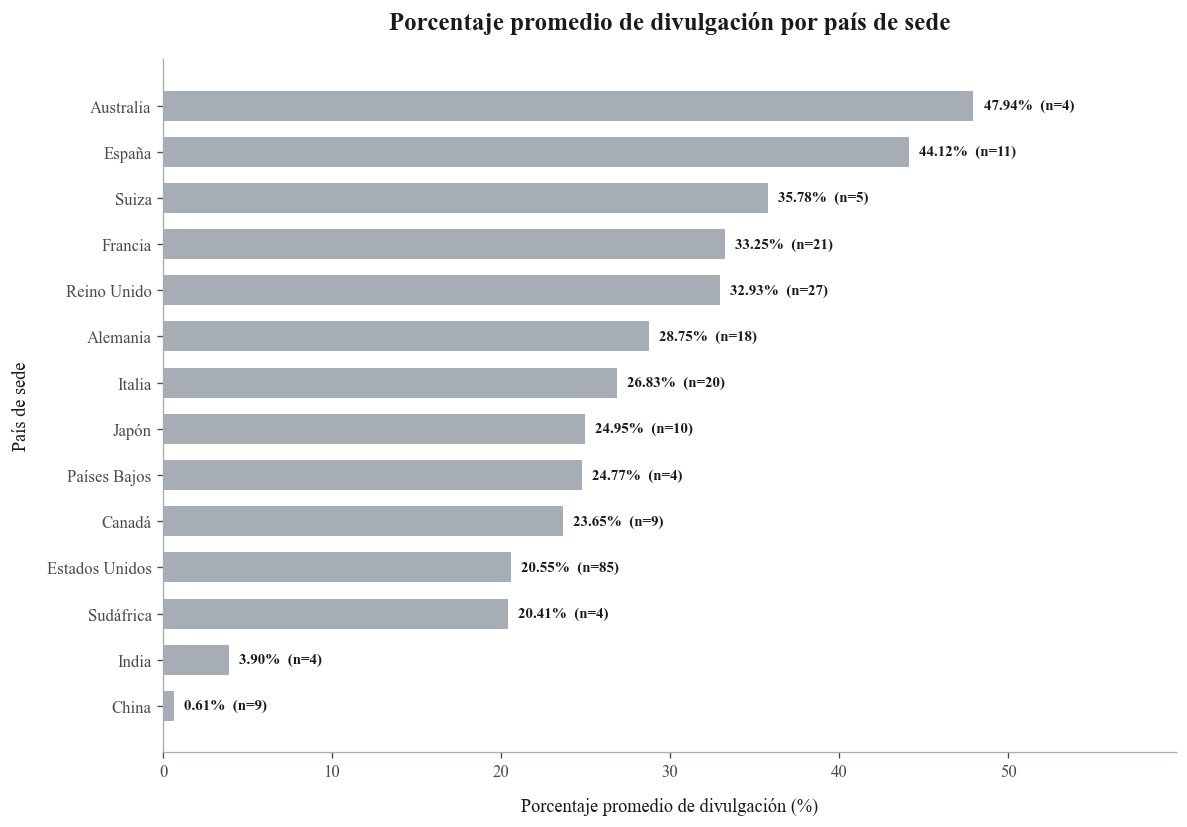

In [70]:
# Visualizamos el porcentaje promedio de divulgación
# para los países con al menos tres empresas

fig, ax = plt.subplots(figsize=(10, 7))

# Utilizamos un color definido previamente
color_paises = COLOR_CATEGORIAS["Governance"]

# Construimos la gráfica
barras = ax.barh(
    resumen_paises_comparables["Pais_sede"],
    resumen_paises_comparables["Porcentaje_promedio_divulgacion"],
    color=color_paises,
    height=0.65
)

# Invertimos el eje para mostrar el mayor porcentaje arriba
ax.invert_yaxis()

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Porcentaje promedio de divulgación por país de sede",
    pad=18
)

ax.set_xlabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

ax.set_ylabel(
    "País de sede",
    labelpad=10
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje y el número de empresas
for barra, porcentaje, empresas in zip(
    barras,
    resumen_paises_comparables["Porcentaje_promedio_divulgacion"],
    resumen_paises_comparables["Empresas"]
):
    ax.text(
        porcentaje + 0.6,
        barra.get_y() + barra.get_height() / 2,
        f"{porcentaje:.2f}%  (n={empresas})",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio para las etiquetas
ax.set_xlim(
    0,
    resumen_paises_comparables[
        "Porcentaje_promedio_divulgacion"
    ].max() * 1.25
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "promedio_divulgacion_pais_sede"
)

plt.show()

Se identificaron empresas con **sede en 27 países**. El porcentaje promedio de divulgación mostró una variación considerable entre ellos, desde 76.15% en Suecia hasta 0.46% en Emiratos Árabes Unidos. No obstante, algunos de estos valores corresponden a países con una representación muy reducida dentro de la muestra (una o dos empresas), por lo que deben interpretarse con cautela.

Los ***países** con **mayor número de empresas** fueron **Estados Unidos (85)**, **Reino Unido (27)**, **Francia (21)**, **Italia (20)** y **Alemania (18)**. Entre ellos también se observaron **diferencias importantes en los niveles promedio de divulgación**. Mientras Reino Unido (32.93%), Francia (33.25%) y Alemania (28.75%) presentaron porcentajes superiores al promedio de la muestra, Estados Unidos registró un promedio de 20.55%, a pesar de concentrar el mayor número de empresas evaluadas.

En conjunto, estos resultados sugieren que el **nivel de divulgación no parece distribuirse de manera uniforme** entre los países de sede. También muestran que los promedios nacionales pueden estar influenciados tanto por el número de empresas representadas como por las características particulares de cada grupo, por lo que este análisis debe interpretarse únicamente como una descripción inicial de la información disponible y no como evidencia suficiente para atribuir las diferencias observadas únicamente al país de sede.

## Indicadores no binarios

### Caracterización de los indicadores no binarios

Además de los indicadores binarios utilizados en el análisis de divulgación y en el proceso de agrupamiento, la base de datos contiene indicadores con formatos de respuesta no binarios. Estos indicadores incluyen **listas de elementos**, puntajes del índice y **otros valores numéricos** que aportan información complementaria sobre distintos aspectos de la transparencia corporativa.

In [71]:
# Identificamos los indicadores no binarios presentes
# en la base de datos

indicadores_no_binarios = (
    base.loc[
        ~base["Metric"].isin(matriz_indicadores.columns),
        ["Metric"]
    ]
    .drop_duplicates()
    .sort_values("Metric")
    .reset_index(drop=True)
)

# Eliminamos el prefijo para facilitar la lectura
indicadores_no_binarios["Indicador"] = (
    indicadores_no_binarios["Metric"]
    .str.replace(
        "Fashion Revolution+",
        "",
        regex=False
    )
)

# Conservamos únicamente el nombre del indicador
indicadores_no_binarios = (
    indicadores_no_binarios[
        ["Indicador"]
    ]
)

print(
    "Número de indicadores no binarios:",
    len(indicadores_no_binarios)
)

display(indicadores_no_binarios)

Número de indicadores no binarios: 20


,Indicador
0,1. Policy & Commitments Score
1,1.1 Own Operations Policies
2,1.3 Management Procedures
3,2. Governance Score
4,2.1 Identifies Lead Responsibility for Human Rights & Environmental Issues
5,3. Traceability Score (2023)
6,3.1 Tier One Factory Disclosure
7,3.2 Processing Facilities Disclosure
8,3.3 Raw Materials Suppliers Disclosure
9,"4. Know, Show & Fix Score"


In [72]:
# Seleccionamos los indicadores cuantitativos
# excluyendo los puntajes del índice

puntajes_indice = [
    "Fashion Transparency Index 2023",
    "1. Policy & Commitments Score",
    "1.1 Own Operations Policies",
    "1.3 Management Procedures",
    "2. Governance Score",
    "2.1 Identifies Lead Responsibility for Human Rights & Environmental Issues",
    "3. Traceability Score (2023)",
    "3.1 Tier One Factory Disclosure",
    "3.2 Processing Facilities Disclosure",
    "3.3 Raw Materials Suppliers Disclosure",
    "4. Know, Show & Fix Score",
    "5. Spotlight Issues Score (2023)"
]

indicadores_cuantitativos = (
    indicadores_no_binarios[
        ~indicadores_no_binarios["Indicador"].isin(
            puntajes_indice
        )
    ]
    .reset_index(drop=True)
)

print(
    "Indicadores cuantitativos:",
    len(indicadores_cuantitativos)
)

display(indicadores_cuantitativos)

Indicadores cuantitativos: 8


,Indicador
0,Discloses Renewable Energy Use
1,Discloses Water Use
2,Full Audit Reports by Named Facilities
3,Publishes Sex-disaggregated Job Distribution
4,Ratings by Named Facilities
5,Selected Audit Findings by Named Facilities
6,Summary of Assessment Findings
7,Supply Chain Policies


En total se identificaron **20 indicadores no binarios**. De ellos, **12** corresponden a puntajes o **subpuntajes calculados por el Fashion Transparency Index**, mientras que los **8** restantes representan **información descriptiva** publicada por las empresas, principalmente en formato de **listas de elementos**. Debido a sus diferencias conceptuales, ambos grupos se analizan por separado.

### Indicadores descriptivos 

Los indicadores descriptivos contienen información publicada por las empresas en formato de **listas de elementos**, en lugar de respuestas de tipo sí/no o puntajes numéricos. Debido a esta característica, su análisis se centra en identificar los **principales elementos divulgados por las empresas** y la **frecuencia con la que aparecen en cada indicador**, con el propósito de describir la información reportada sin modificar su contenido original.

In [73]:
# Revisamos algunos ejemplos de los indicadores descriptivos

for indicador in indicadores_cuantitativos["Indicador"]:

    print("\n" + "=" * 80)
    print(indicador)

    ejemplos = (
        base.loc[
            base["Metric"] == f"Fashion Revolution+{indicador}",
            "Value"
        ]
        .dropna()
        .head(5)
    )

    display(ejemplos)


Discloses Renewable Energy Use


31511    Owned and operated facilities
31517    Owned and operated facilities
31520    Owned and operated facilities
31525    Owned and operated facilities
31533    Owned and operated facilities
Name: Value, dtype: object


Discloses Water Use


5502    Owned and operated facilities, Manufacturing and processing facilities
5511    Owned and operated facilities, Manufacturing and processing facilities
5517                                             Owned and operated facilities
5523    Owned and operated facilities, Manufacturing and processing facilities
5526                                   Manufacturing and processing facilities
Name: Value, dtype: object


Full Audit Reports by Named Facilities


...

16259    Beyond tier 1, At tier 1 level
16279    Beyond tier 1, At tier 1 level
16299                   At tier 1 level
16318                   At tier 1 level
16339    Beyond tier 1, At tier 1 level
Name: Value, dtype: object


Summary of Assessment Findings


16257    Beyond tier 1, At tier 1 level
16277    Beyond tier 1, At tier 1 level
16297                   At tier 1 level
16316    Beyond tier 1, At tier 1 level
16337                   At tier 1 level
Name: Value, dtype: object


Supply Chain Policies


11250                                                                                 Wages & Financial Benefits (e.g. bonuses/insurance/social security/pensions), Energy & Carbon Emissions, Living Conditions/Dormitories, Annual Leave & Public Holidays, Water Usage & Footprint, Contracts & Terms of Employment, Foreign & Migrant Labour, Biodiversity & Conservation, Community Engagement, Maternity Rights & Parental Leave, Anti-bribery Corruption & Presentation of False Information, Water Effluents & Treatment, Manufacturing Restricted Substances List (MRSL) (2021 only), Sub-contracting (2021 only), Discrimination, Working Hours & Rest Breaks, Harassment & Violence, Health & Safety, Child Labour, Waste & Recycling (Packaging/Office/Facility), Forced & Bonded Labour, Freedom of Association Right to Organise & Collective Bargaining, Equal Pay
11270                                                                                             Wages & Financial Benefits (e.g. bonuses/insurance/s

La revisión de ejemplos permitió identificar que estos indicadores almacenan **listas de categorías predefinidas**. Cada respuesta puede contener **uno o varios elementos separados por comas**, los cuales **describen** aspectos específicos de la **información divulgada por la empresa**. Por ejemplo, algunos indicadores señalan el *nivel de la cadena de suministro al que corresponde la información publicada* (como Tier 1 o Raw material level), mientras que otros indican las *operaciones incluidas* (como Own operations o Manufacturing and processing facilities) o los temas cubiertos por las políticas de la cadena de suministro. Debido a esta estructura, el **análisis** se realiza contabilizando la **frecuencia con la que aparece cada elemento dentro de las respuestas.**

**Divulgación del uso de energías renovables**

In [74]:
# Analizamos los elementos divulgados en el indicador
# Discloses Renewable Energy Use

energia_renovable = (
    base.loc[
        base["Metric"] == "Fashion Revolution+Discloses Renewable Energy Use",
        "Value"
    ]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
)

energia_renovable.columns = [
    "Elemento",
    "Empresas"
]

energia_renovable["Porcentaje"] = (
    energia_renovable["Empresas"]
    .div(250)
    .mul(100)
    .round(2)
)

display(energia_renovable)

,Elemento,Empresas,Porcentaje
0,Owned and operated facilities,117,46.800
1,Supply chain,22,8.800


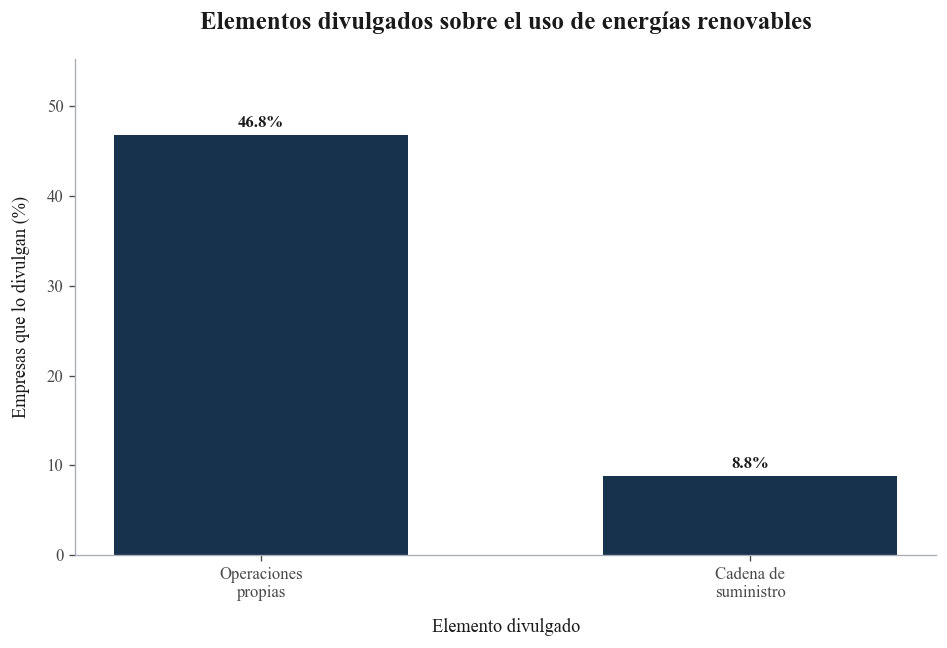

In [75]:
# Visualizamos los elementos divulgados sobre el uso
# de energías renovables

fig, ax = plt.subplots(figsize=(8, 5.5))

# Construimos la gráfica
barras = ax.bar(
    energia_renovable["Elemento"],
    energia_renovable["Porcentaje"],
    color=AZUL_MARINO,
    width=0.6
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Elementos divulgados sobre el uso de energías renovables",
    pad=18
)

ax.set_xlabel(
    "Elemento divulgado",
    labelpad=10
)

ax.set_ylabel(
    "Empresas que lo divulgan (%)",
    labelpad=10
)

# Traducimos las etiquetas del eje X
ax.set_xticks(
    range(len(energia_renovable))
)

ax.set_xticklabels(
    [
        "Operaciones\npropias",
        "Cadena de\nsuministro"
    ]
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje sobre cada barra
for barra, valor in zip(
    barras,
    energia_renovable["Porcentaje"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{valor:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio para las etiquetas
ax.set_ylim(
    0,
    energia_renovable["Porcentaje"].max() * 1.18
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "elementos_energia_renovable"
)

plt.show()

Todas las empresas cuentan con este indicador; sin embargo, la información divulgada no es la misma. El **46.8%** de las empresas **reportó el uso de energías renovables en sus operaciones propias** (Owned and operated facilities), mientras que únicamente el **8.8% extendió esta divulgación a la cadena de suministro** (Supply chain). En consecuencia, aun cuando este indicador está presente para todas las empresas, la **información publicada se concentra** principalmente **en las actividades bajo control directo de la organización**, siendo considerablemente menos frecuente la divulgación relacionada con los proveedores y demás actores de la cadena de suministro.

**Divulgación del uso de agua**

In [76]:
# Analizamos los elementos divulgados en el indicador
# Discloses Water Use

uso_agua = (
    base.loc[
        base["Metric"] == "Fashion Revolution+Discloses Water Use",
        "Value"
    ]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
)

uso_agua.columns = [
    "Elemento",
    "Empresas"
]

uso_agua["Porcentaje"] = (
    uso_agua["Empresas"]
    .div(250)
    .mul(100)
    .round(2)
)

display(uso_agua)

,Elemento,Empresas,Porcentaje
0,Owned and operated facilities,81,32.400
1,Manufacturing and processing facilities,59,23.600
2,Raw material level,8,3.200


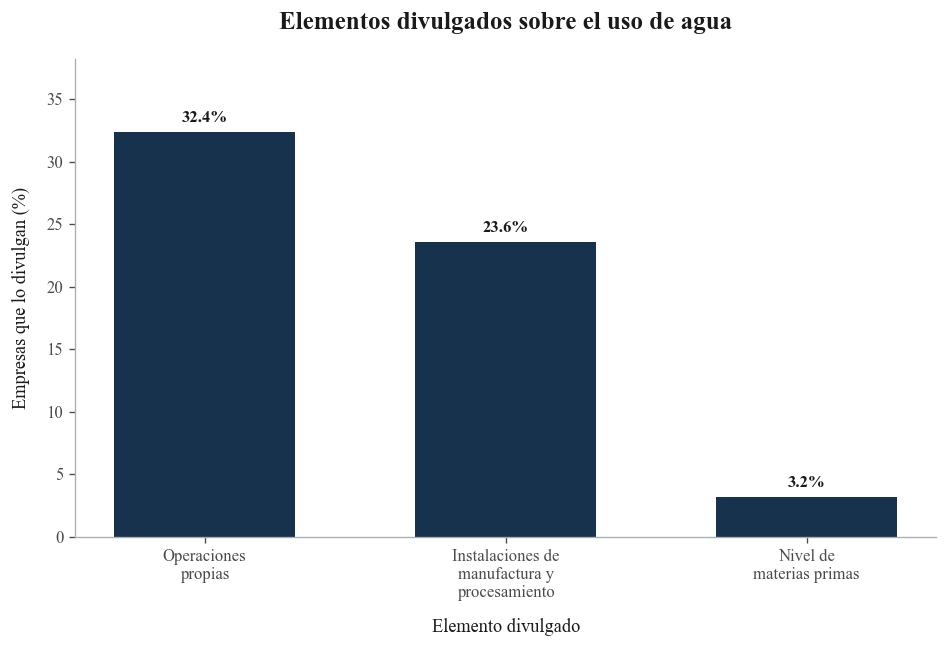

In [77]:
# Visualizamos los elementos divulgados sobre el uso
# de agua

fig, ax = plt.subplots(figsize=(8, 5.5))

# Construimos la gráfica
barras = ax.bar(
    uso_agua["Elemento"],
    uso_agua["Porcentaje"],
    color=AZUL_MARINO,
    width=0.6
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Elementos divulgados sobre el uso de agua",
    pad=18
)

ax.set_xlabel(
    "Elemento divulgado",
    labelpad=10
)

ax.set_ylabel(
    "Empresas que lo divulgan (%)",
    labelpad=10
)

# Traducimos las etiquetas del eje X
ax.set_xticks(
    range(len(uso_agua))
)

ax.set_xticklabels(
    [
        "Operaciones\npropias",
        "Instalaciones de\nmanufactura y\nprocesamiento",
        "Nivel de\nmaterias primas"
    ]
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje sobre cada barra
for barra, valor in zip(
    barras,
    uso_agua["Porcentaje"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{valor:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio para las etiquetas
ax.set_ylim(
    0,
    uso_agua["Porcentaje"].max() * 1.18
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "elementos_uso_agua"
)

plt.show()

La divulgación sobre el **uso de agua** presentó un **mayor alcance** que el indicador anterior, aunque continúa concentrándose principalmente en las **operaciones propias** (Owned and operated facilities), reportadas por el **32.4%** de las empresas. En segundo lugar, el **23.6%** informó datos correspondientes a **instalaciones de manufactura y procesamiento** (Manufacturing and processing facilities), mientras que únicamente el **3.2%** extendió esta divulgación al nivel de **materias primas** (Raw material level). En conjunto, estos resultados muestran que, aun tratándose de un mismo tema, la información publicada disminuye conforme el análisis se desplaza hacia etapas más alejadas de las operaciones directas de la empresa.

**Divulgación de información sobre auditorías**

In [78]:
# Analizamos los elementos divulgados en los indicadores
# relacionados con auditorías

# Una auditoría es una revisión o evaluación realizada para
# verificar si las fábricas o proveedores cumplen con los
# estándares laborales, ambientales o de derechos humanos
# establecidos por la empresa.

indicadores_auditorias = [
    "Fashion Revolution+Full Audit Reports by Named Facilities",
    "Fashion Revolution+Ratings by Named Facilities",
    "Fashion Revolution+Selected Audit Findings by Named Facilities",
    "Fashion Revolution+Summary of Assessment Findings"
]

auditorias = (
    base.loc[
        base["Metric"].isin(indicadores_auditorias),
        ["Metric", "Value"]
    ]
    .copy()
)

# Eliminamos el prefijo del nombre del indicador
auditorias["Indicador"] = (
    auditorias["Metric"]
    .str.replace(
        "Fashion Revolution+",
        "",
        regex=False
    )
)

# Separamos los elementos contenidos en cada respuesta
auditorias = (
    auditorias
    .assign(
        Elemento=auditorias["Value"].str.split(",")
    )
    .explode("Elemento")
)

auditorias["Elemento"] = (
    auditorias["Elemento"]
    .str.strip()
)

# Calculamos las frecuencias
resumen_auditorias = (
    auditorias
    .groupby(
        ["Indicador", "Elemento"],
        as_index=False
    )
    .size()
    .rename(
        columns={"size": "Empresas"}
    )
)

resumen_auditorias["Porcentaje"] = (
    resumen_auditorias["Empresas"]
    .div(250)
    .mul(100)
    .round(2)
)

display(resumen_auditorias)

,Indicador,Elemento,Empresas,Porcentaje
0,Full Audit Reports by Named Facilities,At tier 1 level,5,2.000
1,Full Audit Reports by Named Facilities,Beyond tier 1,1,0.400
2,Full Audit Reports by Named Facilities,Raw material level,2,0.800
3,Ratings by Named Facilities,At tier 1 level,11,4.400
4,Ratings by Named Facilities,Beyond tier 1,7,2.800
5,Ratings by Named Facilities,Raw material level,5,2.000
6,Selected Audit Findings by Named Facilities,At tier 1 level,58,23.200
7,Selected Audit Findings by Named Facilities,Beyond tier 1,36,14.400
8,Selected Audit Findings by Named Facilities,Raw material level,2,0.800
9,Summary of Assessment Findings,At tier 1 level,121,48.400


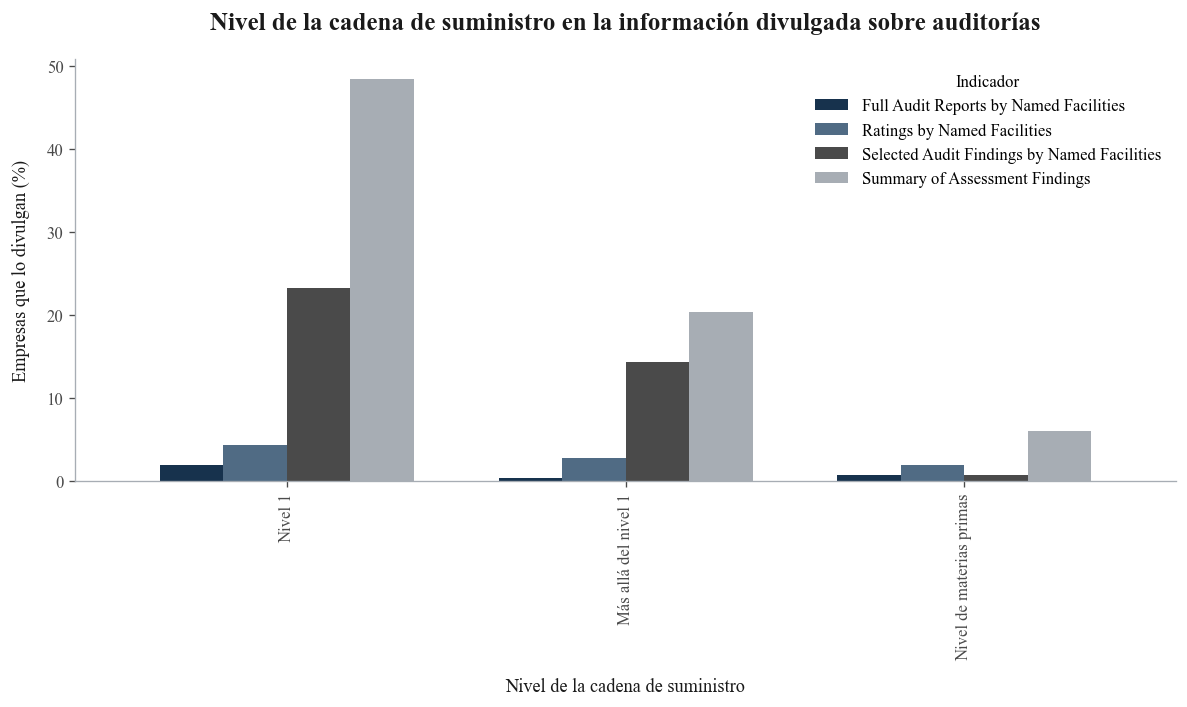

In [79]:
# Visualizamos los elementos divulgados en los indicadores
# relacionados con auditorías

niveles = [
    "At tier 1 level",
    "Beyond tier 1",
    "Raw material level"
]

traduccion = {
    "At tier 1 level": "Nivel 1",
    "Beyond tier 1": "Más allá del nivel 1",
    "Raw material level": "Nivel de materias primas"
}

tabla_grafica = (
    resumen_auditorias
    .pivot(
        index="Elemento",
        columns="Indicador",
        values="Porcentaje"
    )
    .reindex(niveles)
)

tabla_grafica.index = [
    traduccion[nivel]
    for nivel in tabla_grafica.index
]

fig, ax = plt.subplots(figsize=(10, 6))

tabla_grafica.plot(
    kind="bar",
    ax=ax,
    color=[
        AZUL_MARINO,
        AZUL_SECUNDARIO,
        GRIS_OSCURO,
        GRIS_MEDIO
    ],
    width=0.75
)

ax.set_title(
    "Nivel de la cadena de suministro en la información divulgada sobre auditorías",
    pad=18
)

ax.set_xlabel(
    "Nivel de la cadena de suministro",
    labelpad=10
)

ax.set_ylabel(
    "Empresas que lo divulgan (%)",
    labelpad=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

ax.legend(
    title="Indicador",
    frameon=False
)

fig.tight_layout()

guardar_figura(
    fig,
    "niveles_auditorias"
)

plt.show()

Los cuatro indicadores relacionados con auditorías muestran un patrón similar. La **información se concentra** principalmente **en las instalaciones de nivel 1** (At tier 1 level), independientemente del tipo de documento divulgado. El **mayor porcentaje** corresponde al **resumen de hallazgos de evaluación**, publicado por el **48.4%** de las empresas **para instalaciones de nivel 1**, seguido por los **hallazgos seleccionados de auditoría** con **23.2%**. En contraste, la **divulgación disminuye** considerablemente **cuando la información se extiende a proveedores** más allá del nivel 1 (Beyond tier 1) y es **aún menor para el nivel de materias primas** (Raw material level). En conjunto, estos resultados muestran que la **transparencia sobre auditorías se concentra** principalmente **en el primer nivel de la cadena de suministro**, mientras que la información correspondiente a niveles posteriores continúa siendo menos frecuente.

**Distribución del empleo por sexo**

In [80]:
# Analizamos los elementos divulgados en el indicador
# Publishes Sex-disaggregated Job Distribution.

# Este indicador muestra en qué parte de la empresa se publica
# la distribución del personal diferenciada por sexo.

distribucion_sexo = (
    base.loc[
        base["Metric"] == "Fashion Revolution+Publishes Sex-disaggregated Job Distribution",
        "Value"
    ]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
)

distribucion_sexo.columns = [
    "Elemento",
    "Empresas"
]

distribucion_sexo["Porcentaje"] = (
    distribucion_sexo["Empresas"]
    .div(250)
    .mul(100)
    .round(2)
)

display(distribucion_sexo)

,Elemento,Empresas,Porcentaje
0,Own operations,151,60.400
1,Supply chain,9,3.600


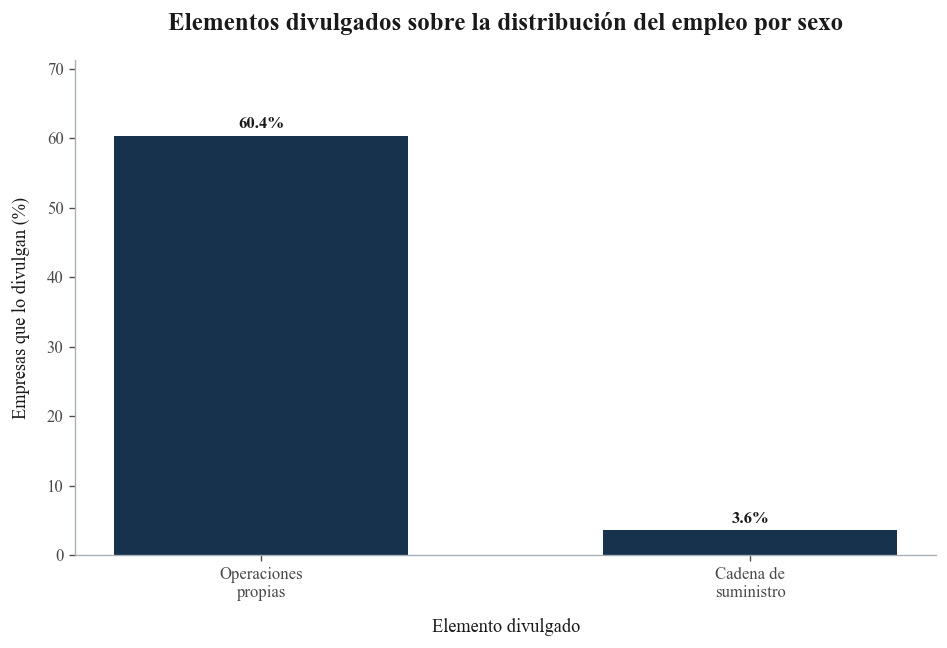

In [81]:
# Visualizamos los elementos divulgados sobre la
# distribución del empleo por sexo

fig, ax = plt.subplots(figsize=(8, 5.5))

# Construimos la gráfica
barras = ax.bar(
    distribucion_sexo["Elemento"],
    distribucion_sexo["Porcentaje"],
    color=AZUL_MARINO,
    width=0.6
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Elementos divulgados sobre la distribución del empleo por sexo",
    pad=18
)

ax.set_xlabel(
    "Elemento divulgado",
    labelpad=10
)

ax.set_ylabel(
    "Empresas que lo divulgan (%)",
    labelpad=10
)

# Traducimos las etiquetas del eje X
ax.set_xticks(
    range(len(distribucion_sexo))
)

ax.set_xticklabels(
    [
        "Operaciones\npropias",
        "Cadena de\nsuministro"
    ]
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje sobre cada barra
for barra, valor in zip(
    barras,
    distribucion_sexo["Porcentaje"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{valor:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio para las etiquetas
ax.set_ylim(
    0,
    distribucion_sexo["Porcentaje"].max() * 1.18
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "distribucion_empleo_sexo"
)

plt.show()

La divulgación sobre la distribución del empleo por sexo **se concentra** principalmente en las **operaciones propias** (Own operations), reportadas por el **60.4%** de las empresas. En contraste, únicamente el **3.6% extendió esta información a la cadena de suministro** (Supply chain). Este resultado muestra que la **información desagregada por sexo se publica con mayor frecuencia para el personal directamente empleado por la organización**, mientras que continúa siendo poco habitual divulgar esta información para los trabajadores de proveedores y otras etapas de la cadena de suministro.

**Temas incluidos en las políticas de la cadena de suministro**

In [82]:
# Analizamos los elementos divulgados en el indicador
# Supply Chain Policies.

# Este indicador muestra los temas que las empresas incluyen
# dentro de sus políticas dirigidas a proveedores y fábricas.

politicas_cadena = (
    base.loc[
        base["Metric"] == "Fashion Revolution+Supply Chain Policies",
        "Value"
    ]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
)

politicas_cadena.columns = [
    "Tema",
    "Empresas"
]

politicas_cadena["Porcentaje"] = (
    politicas_cadena["Empresas"]
    .div(250)
    .mul(100)
    .round(2)
)

display(politicas_cadena)

,Tema,Empresas,Porcentaje
0,Child Labour,222,88.800
1,Forced & Bonded Labour,219,87.600
2,Health & Safety,217,86.800
3,Freedom of Association Right to Organise & Collective Bargaining,212,84.800
4,Wages & Financial Benefits (e.g. bonuses/insurance/social security/pensions),210,84.000
5,Harassment & Violence,210,84.000
6,Discrimination,210,84.000
7,Working Hours & Rest Breaks,205,82.000
8,Anti-bribery Corruption & Presentation of False Information,189,75.600
9,Sub-contracting (2021 only),175,70.000


Las políticas de la cadena de suministro abarcan una amplia variedad de temas relacionados con las condiciones laborales, los derechos humanos y el medio ambiente. Los **aspectos más frecuentes** fueron el **trabajo infantil** (Child Labour), incluido por el **88.8%** de las empresas; el **trabajo forzoso** (Forced & Bonded Labour), con **87.6%**; la **salud y seguridad** (Health & Safety), con **86.8%**; la **libertad de asociación y negociación colectiva** (Freedom of Association, Right to Organise & Collective Bargaining), con **84.8%**; y los **salarios y prestaciones** (Wages & Financial Benefits), junto con la **prevención del acoso y la violencia** (Harassment & Violence) y la **no discriminación** (Discrimination), todos con **84.0%**. En contraste, temas como la **participación comunitaria** (Community Engagement), el **trabajo a domicilio** (Homeworking) y el **reciclaje de productos textiles** (Waste & Recycling – Product/Textiles) fueron considerablemente **menos frecuentes**. En conjunto, estos resultados muestran que las **políticas** de la cadena de suministro **tienden a concentrarse en los derechos laborales** fundamentales y las condiciones básicas de trabajo, mientras que otros temas específicos aparecen con menor frecuencia.

### Puntajes del Fashion Transparency Index

Los indicadores restantes corresponden a los puntajes calculados por el Fashion Transparency Index para resumir el desempeño de las empresas en distintas dimensiones de la transparencia. A diferencia de los indicadores binarios y descriptivos analizados anteriormente, estos valores representan **resultados agregados obtenidos mediante la metodología oficial del índice**. Por ello, el análisis se limita a describir su distribución, sin reinterpretar los criterios de puntuación establecidos por Fashion Revolution.

In [83]:
# Seleccionamos los puntajes del Fashion Transparency Index

puntajes_indice = [
    "Fashion Revolution+Fashion Transparency Index 2023",
    "Fashion Revolution+1. Policy & Commitments Score",
    "Fashion Revolution+2. Governance Score",
    "Fashion Revolution+3. Traceability Score (2023)",
    "Fashion Revolution+4. Know, Show & Fix Score",
    "Fashion Revolution+5. Spotlight Issues Score (2023)"
]

puntajes = (
    base[
        base["Metric"].isin(puntajes_indice)
    ][
        ["Company", "Metric", "Value"]
    ]
    .copy()
)

puntajes["Indicador"] = (
    puntajes["Metric"]
    .str.replace(
        "Fashion Revolution+",
        "",
        regex=False
    )
)

puntajes["Value"] = pd.to_numeric(
    puntajes["Value"],
    errors="coerce"
)

resumen_puntajes = (
    puntajes
    .groupby(
        "Indicador",
        as_index=False
    )
    .agg(
        Promedio=("Value", "mean"),
        Mediana=("Value", "median"),
        Minimo=("Value", "min"),
        Maximo=("Value", "max")
    )
    .round(2)
)

display(resumen_puntajes)

,Indicador,Promedio,Mediana,Minimo,Maximo
0,1. Policy & Commitments Score,5.320,5.830,0.000,9.770
1,2. Governance Score,3.630,3.640,0.000,10.000
2,3. Traceability Score (2023),2.290,1.080,0.000,9.590
3,"4. Know, Show & Fix Score",2.490,2.140,0.000,8.810
4,5. Spotlight Issues Score (2023),1.810,1.330,0.000,7.440
5,Fashion Transparency Index 2023,2.610,2.370,0.000,8.300


Los puntajes del índice muestran un comportamiento consistente con el análisis realizado a partir de los indicadores binarios. En promedio, **Policies & Commitments (Políticas y compromisos)** obtuvo la puntuación más alta (**5.32**), seguido de **Governance (Gobernanza)** (**3.63**). En contraste, **Spotlight Issues (Temas prioritarios)** (**1.81**) y **Traceability (Trazabilidad de la cadena de suministro)** (**2.29**) presentaron los valores promedio más bajos, mientras que **Know, Show & Fix (Conocer, demostrar y corregir)** alcanzó un valor intermedio (**2.49**).

En conjunto, estos resultados son consistentes con el análisis desarrollado previamente. Las dimensiones relacionadas con políticas, estructuras de gobierno y procesos internos presentan, en promedio, mayores niveles de divulgación que aquellas orientadas a la trazabilidad y a los temas prioritarios, los cuales requieren informar resultados, impactos o evidencia más específica sobre la cadena de suministro.

### Referencias

Comisión Europea. (2022). Estrategia para la circularidad y sostenibilidad de los productos textiles (COM/2022/141 final).
https://eur-lex.europa.eu/legal-content/ES/TXT/?uri=CELEX:52022DC0141

GHG Protocol. (2004). A corporate accounting and reporting standard: Revised edition.
https://ghgprotocol.org/corporate-standard

GHG Protocol. (2011). Corporate value chain (Scope 3) accounting and reporting standard.
https://ghgprotocol.org/corporate-value-chain-scope-3-standard

Global Reporting Initiative. (2021). GRI 2: General Disclosures 2021.
https://www.globalreporting.org/publications/documents/english/gri-2-general-disclosures-2021/

Global Reporting Initiative. (2021). GRI 3: Material Topics 2021.
https://www.globalreporting.org/publications/documents/english/gri-3-material-topics-2021/

Oficina del Alto Comisionado de las Naciones Unidas para los Derechos Humanos. (2011). Principios Rectores sobre las Empresas y los Derechos Humanos.
https://www.ohchr.org/Documents/Issues/Business/Intro_Guiding_PrinciplesBusinessHR.pdf

Organización Internacional del Trabajo. (1949). Convenio sobre el derecho de sindicación y de negociación colectiva, 1949 (núm. 98).
https://normlex.ilo.org/dyn/nrmlx_es/f?p=NORMLEXPUB:12100:0::NO::P12100_INSTRUMENT_ID:312243

Organización Internacional del Trabajo. (1970). Convenio sobre la fijación de salarios mínimos, 1970 (núm. 131).
https://normlex.ilo.org/dyn/nrmlx_es/f?p=NORMLEXPUB:12100:0::NO::P12100_INSTRUMENT_ID:312276

Organización Internacional del Trabajo. (2015). Piece rate pay.
https://www.ilo.org/resource/17-piece-rate-pay

Organización Internacional del Trabajo. (2022). Declaración tripartita de principios sobre las empresas multinacionales y la política social.
https://www.ilo.org/es/acerca-de-la-oit/organigrama-de-la-oficina-internacional-de-trabajo/departamento-de-empresas-sostenibles-productividad-y-transicion-justa-de-la/declaracion-tripartita-de-principios-sobre-las-empresas-multinacionales-y

Organización Internacional del Trabajo. (2023). Declaración tripartita de principios sobre las empresas multinacionales y la política social.
https://www.ilo.org/es/publications/declaracion-tripartita-de-principios-sobre-las-empresas-multinacionales-y-1

Organización para la Cooperación y el Desarrollo Económicos. (2018). OECD due diligence guidance for responsible supply chains in the garment and footwear sector. OECD Publishing.
https://doi.org/10.1787/9789264290587-en

Organización para la Cooperación y el Desarrollo Económicos. (2020). How can fashion brands mitigate the negative impacts of the COVID-19 pandemic on garment workers?
https://www.oecd.org/en/blogs/2020/04/how-can-fashion-brands-mitigate-the-negative-impacts-of-the-covid-19-pandemic-on-garment-workers.html

Organización para la Cooperación y el Desarrollo Económicos. (2023). G20/OECD Principles of Corporate Governance 2023. OECD Publishing.
https://doi.org/10.1787/ed750b30-en

Parlamento Europeo y Consejo de la Unión Europea. (2013). Directiva 2013/34/UE, relativa a los estados financieros anuales y los informes conexos de ciertos tipos de empresas.
https://eur-lex.europa.eu/legal-content/ES/TXT/?uri=CELEX:32013L0034

Parlamento Europeo y Consejo de la Unión Europea. (2014). Directiva 2014/95/UE sobre divulgación de información no financiera.
https://eur-lex.europa.eu/legal-content/ES/TXT/?uri=CELEX:32014L0095

Parlamento Europeo y Consejo de la Unión Europea. (2020). Reglamento (UE) 2020/852 relativo al establecimiento de un marco para facilitar las inversiones sostenibles.
https://eur-lex.europa.eu/legal-content/ES/TXT/?uri=CELEX:32020R0852

República Federal de Alemania. (2021). Gesetz über die unternehmerischen Sorgfaltspflichten zur Vermeidung von Menschenrechtsverletzungen in Lieferketten (LkSG).
Sección 6: https://www.gesetze-im-internet.de/lksg/__6.html
Sección 8: https://www.gesetze-im-internet.de/lksg/__8.html

Securities and Exchange Commission. (2009). Proxy Disclosure Enhancements.
https://www.sec.gov/rules-regulations/2009/12/proxy-disclosure-enhancements

